# Predicting 30-Day Unplanned Readmission After an ICU Stay
## A self-learning tutorial on MIMIC-IV v3.1

**Course:** AI 380H — AI in Healthcare
**Format:** step-by-step tutorial notebook. Every cell is commented so that a peer
can rebuild this project from scratch without asking you any questions.

---

### What this tutorial teaches

By the end of this notebook you will be able to:

1. **Frame** a clinical prediction problem precisely (who, when, what outcome, what horizon).
2. **Build a cohort** from raw MIMIC-IV tables, with an auditable inclusion/exclusion flow.
3. **Engineer features that respect time** — the single most common source of silent failure
   in healthcare ML is using information that would not exist at prediction time.
4. **Split data by patient**, not by row, so the same person cannot appear in train and test.
5. **Train and compare four model families**: penalised logistic regression (the baseline you
   must beat), random forest, gradient boosting, and a small feed-forward neural network.
6. **Evaluate for an imbalanced clinical problem** — AUROC is not enough. We use AUPRC,
   calibration, Brier score, and a decision-relevant operating point (alert rate / PPV /
   number-needed-to-evaluate).
7. **Explain** the model with coefficients, permutation importance, and partial dependence.
8. **Audit** performance across patient subgroups, and interpret those numbers honestly.
9. **Stress-test** with a temporal split (train on older years, test on newer ones).

### The clinical question

> For an adult who survived a hospitalisation that included an ICU stay, what is the
> probability that they will be **readmitted unexpectedly to the hospital within 30 days
> of discharge**?

Thirty-day readmission is a standard quality and payment metric (in the U.S., CMS's Hospital
Readmissions Reduction Program penalises hospitals with excess readmissions). Patients who
have been critically ill are a high-risk group: they leave with new medications, deconditioning,
and unresolved problems. A model that flags high-risk patients *before* discharge lets a care
team spend its limited transitional-care resources where they are most likely to help.

**Prediction time = the moment of hospital discharge.** Everything we feed the model must be
knowable at or before that moment. Nothing from after discharge is allowed.

### Why this is not the standard MIMIC tutorial

Most introductory MIMIC tutorials predict **in-hospital mortality** from the first 24 hours of
ICU vitals. This project differs on purpose:

| | Typical introductory MIMIC tutorial | This tutorial |
|---|---|---|
| Outcome | In-hospital death | Post-discharge readmission (label is outside the index encounter) |
| Anchor | ICU admission | Hospital discharge |
| Tables | `icustays`, `chartevents` | `admissions`, `patients`, `icustays`, `diagnoses_icd`, `labevents`, `prescriptions` |
| Modelling focus | One model, AUROC | Four model families, calibration, subgroup audit, temporal shift |
| Extra skill taught | — | Charlson comorbidity coding from ICD-9 **and** ICD-10, group-aware splitting |

---

### Before you run anything

* **Point the notebook at your data.** Cell 1.2 looks for your MIMIC-IV folder in a
  `MIMIC_DIR` environment variable, then in a one-line `mimic_path.txt` file next to this
  notebook, then in a placeholder you can edit. The first two keep your personal folder path
  out of the notebook, so the `.ipynb` can be shared as-is.
* **Data use.** MIMIC-IV is credentialed data under a PhysioNet Data Use Agreement. Do not
  commit the data or any row-level output to a public repository, and do not paste patient
  rows into a hosted LLM. Aggregate results (counts, metrics, plots) are fine. This notebook
  never prints individual patient rows (you will see table *schemas* instead of `.head()`),
  and everything row-level it writes goes into `readmission_project/cache/`. Even so, clear
  all outputs before you share or commit it.
* **Runtime.** The core pipeline (small tables only) runs in roughly 2–5 minutes on a laptop.
  The two optional enrichment steps stream very large files and can take 10–40 minutes the
  first time; both are cached to disk afterwards.
* **Reproducibility.** Run *Kernel → Restart & Run All* once you are done editing. If the
  notebook does not survive that, it is not yet a tutorial.

### Packages

Required: `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `joblib`.
Optional (the notebook degrades gracefully without them): `pyarrow` (fast caching),
`xgboost` (an extra model), `shap` (per-patient explanations).

```
pip install -r requirements.txt          # from the repository, or:
pip install pandas numpy scikit-learn matplotlib joblib pyarrow
```

---
## 1. Setup and configuration

Everything you might want to change lives in one cell (1.2). A peer should be able to point
`MIMIC_DIR` at their own copy of MIMIC-IV (environment variable, `mimic_path.txt`, or the
placeholder) and run the whole notebook unchanged.

In [1]:
# ----------------------------------------------------------------------------------
# 1.1 Imports
# ----------------------------------------------------------------------------------
import os
import sys
import json
import time
import gzip
import warnings
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import sklearn

# Keep the output readable. We silence only the noisy, expected warnings
# (e.g. sklearn telling us a rare category was unseen at transform time).
warnings.filterwarnings("ignore", category=FutureWarning)


# Any warning that does appear is printed WITHOUT the file path it came from. By default Python
# prints the full path of the library file (e.g. C:\Users\<your name>\...\site-packages\...),
# and everything printed is saved inside the .ipynb - so a stray warning would put your user
# name into any copy of the notebook you share.
def _warning_without_path(message, category, filename, lineno, line=None):
    return f"{category.__name__}: {message}\n"


warnings.formatwarning = _warning_without_path

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

print("python      :", sys.version.split()[0])
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib  :", matplotlib.__version__)

# This notebook uses `get_feature_names_out`, `StratifiedGroupKFold` and
# `HistGradientBoostingClassifier`, which need scikit-learn 1.1 or newer.
_skl = tuple(int(x) for x in sklearn.__version__.split(".")[:2])
if _skl < (1, 1):
    print("\n[!] scikit-learn < 1.1 detected. Please run: pip install -U scikit-learn")

python      : 3.13.9
pandas      : 2.3.3
numpy       : 2.5.3
scikit-learn: 1.7.2
matplotlib  : 3.10.7


In [4]:
# ----------------------------------------------------------------------------------
# 1.2 Configuration
# ----------------------------------------------------------------------------------
# --- Where is YOUR copy of MIMIC-IV? ------------------------------------------------
# Point this at the folder that directly contains the `hosp/` and `icu/` subfolders.
# The notebook checks three places, in this order, and uses the first one it finds:
#   1. an environment variable named MIMIC_DIR
#   2. a one-line text file named `mimic_path.txt`, next to this notebook, holding the path
#   3. MIMIC_DIR_PLACEHOLDER below - simply edit it if you prefer
# Options 1 and 2 keep your personal folder path out of the notebook itself, so the .ipynb
# can be shared or committed as-is (`mimic_path.txt` is listed in the repo's .gitignore).
MIMIC_DIR_PLACEHOLDER = r"G:\My Drive\Python\MSDS\AI 380H AI in Healthcare\Data\mimic-iv-3.1"   # e.g. r"D:\data\mimic-iv-3.1" or "~/data/mimic-iv-3.1"


def find_mimic_dir():
    """Return (path, where_it_came_from), using the lookup order described above."""
    env_value = os.environ.get("MIMIC_DIR", "").strip().strip('"').strip("'")
    if env_value:
        return Path(env_value).expanduser(), "the MIMIC_DIR environment variable"
    path_file = Path("mimic_path.txt")        # relative to the notebook's own folder
    if path_file.exists():
        # "utf-8-sig" swallows the invisible byte-order mark some Windows editors add, and
        # the strip() calls tolerate the quotes that File Explorer's "Copy as path" adds.
        text = path_file.read_text(encoding="utf-8-sig").strip().strip('"').strip("'")
        if text:
            return Path(text).expanduser(), "mimic_path.txt"
    return Path(MIMIC_DIR_PLACEHOLDER).expanduser(), "MIMIC_DIR_PLACEHOLDER in cell 1.2"


MIMIC_DIR, MIMIC_DIR_SOURCE = find_mimic_dir()

# Where this notebook writes its own outputs. Nothing is ever written back into MIMIC_DIR.
PROJECT_DIR = Path.cwd() / "readmission_project"
CACHE_DIR = PROJECT_DIR / "cache"     # intermediate tables, so you only pay for the slow steps once
                                      # (ROW-LEVEL patient data: it stays on your machine)
FIG_DIR = PROJECT_DIR / "figures"     # PNGs, ready to drop straight into the slide deck
MODEL_DIR = PROJECT_DIR / "models"    # fitted pipelines + run_record.json (trained on
                                      # credentialed data, so keep these local too)
for d in (PROJECT_DIR, CACHE_DIR, FIG_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Study design knobs -----------------------------------------------------------
READMIT_WINDOW_DAYS = 30   # the prediction horizon. Try 7 or 90 as an exercise.
MIN_AGE = 18               # adults only
REQUIRE_ICU = True         # index hospitalisation must contain >= 1 ICU stay

# --- Optional (slow) enrichment ---------------------------------------------------
# Both stream a multi-gigabyte file in chunks and then cache the tiny result.
# Start with both False, get the pipeline working end to end, then switch them on.
USE_LABS = True            # last lab values before discharge      (~10-25 min first run)
USE_PRESCRIPTIONS = True   # discharge polypharmacy count          (~3-8 min first run)
CHUNKSIZE = 2_000_000      # rows per chunk when streaming. Lower this if you run out of RAM.

# --- Modelling knobs --------------------------------------------------------------
RANDOM_SEED = 42
TEST_SIZE = 0.20           # fraction of *patients* (not rows) held out
N_CV_FOLDS = 5
USE_RACE_AS_FEATURE = False  # see Section 11 for why this defaults to False
GRAYSCALE_FIGURES = True     # print-safe figures that also match the slide deck

np.random.seed(RANDOM_SEED)

# --- Figure styling ---------------------------------------------------------------
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# A small palette + linestyle cycle. Using both means every figure still reads
# correctly when printed in black and white or shown on a grayscale slide.
if GRAYSCALE_FIGURES:
    SERIES_STYLE = [
        {"color": "#000000", "linestyle": "-"},
        {"color": "#555555", "linestyle": "--"},
        {"color": "#888888", "linestyle": "-."},
        {"color": "#aaaaaa", "linestyle": ":"},
        {"color": "#333333", "linestyle": (0, (3, 1, 1, 1))},
    ]
    BAR_COLOR = "#444444"
else:
    SERIES_STYLE = [
        {"color": c, "linestyle": ls}
        for c, ls in zip(["#1b6ca8", "#c0392b", "#27743f", "#8e44ad", "#d68910"],
                         ["-", "--", "-.", ":", (0, (3, 1, 1, 1))])
    ]
    BAR_COLOR = "#1b6ca8"


def style(i):
    """Return the plot kwargs for the i-th series (wraps around)."""
    return SERIES_STYLE[i % len(SERIES_STYLE)]


def rel(path):
    """A path relative to the notebook's folder, for printing.

    Printing absolute paths would write your user name and folder layout into the notebook's
    saved output, and from there into anything you share (GitHub, peer review, screenshots).
    """
    try:
        return Path(path).resolve().relative_to(Path.cwd().resolve()).as_posix()
    except ValueError:
        return Path(path).name


def save_fig(fig, name):
    """Save a figure into FIG_DIR under a predictable name and report the path.

    The slide deck refers to these exact filenames, so keep them stable.
    """
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path)
    print(f"  saved -> {rel(path)}")
    return path


print(f"MIMIC-IV folder taken from: {MIMIC_DIR_SOURCE}")
print(f"Outputs will be written to: {rel(PROJECT_DIR)}/  (next to this notebook)")

MIMIC-IV folder taken from: MIMIC_DIR_PLACEHOLDER in cell 1.2
Outputs will be written to: readmission_project/  (next to this notebook)


In [6]:
# ----------------------------------------------------------------------------------
# 1.3 Locate the data files and fail loudly if the path is wrong
# ----------------------------------------------------------------------------------
# MIMIC-IV ships as two module folders of gzipped CSVs:
#   hosp/  -> hospital-wide data (admissions, labs, diagnoses, medications, ...)
#   icu/   -> ICU-specific data  (icustays, chartevents, inputevents, ...)
# Depending on how you downloaded it, files may be `.csv.gz` or already decompressed `.csv`.

MODULES = ("hosp", "icu")


def resolve_table(name):
    """Return the Path to a MIMIC table, accepting .csv.gz or .csv, in hosp/ or icu/.

    Parameters
    ----------
    name : str
        Bare table name, e.g. "admissions" or "icustays".

    Raises
    ------
    FileNotFoundError
        With a message that tells the reader exactly what to fix.
    """
    for module in MODULES:
        for ext in (".csv.gz", ".csv"):
            candidate = MIMIC_DIR / module / f"{name}{ext}"
            if candidate.exists():
                return candidate
    raise FileNotFoundError(
        f"Could not find table '{name}' under {MIMIC_DIR}.\n"
        f"Expected something like {MIMIC_DIR / 'hosp' / (name + '.csv.gz')}.\n"
        f"Check that MIMIC_DIR points at the folder that CONTAINS hosp/ and icu/."
    )


if not MIMIC_DIR.exists():
    raise FileNotFoundError(
        f"MIMIC_DIR does not exist: {MIMIC_DIR}  (taken from {MIMIC_DIR_SOURCE})\n"
        "Set the MIMIC_DIR environment variable, create mimic_path.txt next to this notebook, "
        "or edit MIMIC_DIR_PLACEHOLDER in cell 1.2 - then re-run from the top."
    )

# Print only the folder's name, not its full path (see rel() in 1.2 for why).
print(f"MIMIC-IV root: .../{MIMIC_DIR.name}\n")
for module in MODULES:
    mdir = MIMIC_DIR / module
    if not mdir.exists():
        print(f"  [!] missing module folder: {mdir}")
        continue
    files = sorted(p for p in mdir.iterdir() if p.suffix in {".gz", ".csv"})
    total_gb = sum(p.stat().st_size for p in files) / 1e9
    print(f"  {module}/  {len(files)} files, {total_gb:.1f} GB on disk")
    for p in files[:6]:
        print(f"      {p.name:<28} {p.stat().st_size / 1e6:8.1f} MB")
    if len(files) > 6:
        print(f"      ... and {len(files) - 6} more")
    print()

MIMIC-IV root: .../mimic-iv-3.1

  hosp/  22 files, 6.3 GB on disk
      admissions.csv.gz                19.9 MB
      d_hcpcs.csv.gz                    0.4 MB
      d_icd_diagnoses.csv.gz            0.9 MB
      d_icd_procedures.csv.gz           0.6 MB
      d_labitems.csv.gz                 0.0 MB
      diagnoses_icd.csv.gz             33.6 MB
      ... and 16 more

  icu/  9 files, 4.4 GB on disk
      caregiver.csv.gz                  0.0 MB
      chartevents.csv.gz             3502.4 MB
      d_items.csv.gz                    0.1 MB
      datetimeevents.csv.gz            63.5 MB
      icustays.csv.gz                   3.3 MB
      ingredientevents.csv.gz         311.6 MB
      ... and 3 more



In [7]:
# ----------------------------------------------------------------------------------
# 1.4 A thin reader with caching
# ----------------------------------------------------------------------------------
# Two helpers used everywhere below:
#   read_table()  - load a whole (small) table, with explicit dtypes and date parsing
#   cached()      - run an expensive function once, then read the parquet/csv next time
#
# Being explicit about `usecols` and `dtype` is not fussiness: on tables with tens of
# millions of rows it is the difference between "loads in 8 seconds" and "kills the kernel".

def read_table(name, usecols=None, dtype=None, parse_dates=None, nrows=None, **kwargs):
    """Read one MIMIC table into a DataFrame."""
    path = resolve_table(name)
    t0 = time.time()
    df = pd.read_csv(
        path,
        usecols=usecols,
        dtype=dtype,
        parse_dates=parse_dates,
        nrows=nrows,
        low_memory=False,
        **kwargs,
    )
    print(f"  {name:<18} {len(df):>10,} rows x {df.shape[1]:>2} cols  ({time.time() - t0:5.1f}s)")
    return df


def iter_table(name, usecols=None, dtype=None, parse_dates=None, chunksize=CHUNKSIZE):
    """Yield a huge MIMIC table in chunks so it never has to fit in memory at once."""
    path = resolve_table(name)
    return pd.read_csv(
        path,
        usecols=usecols,
        dtype=dtype,
        parse_dates=parse_dates,
        chunksize=chunksize,
        low_memory=False,
    )


def cached(name, build_fn, force=False):
    """Materialise `build_fn()` to disk once, and reuse it on every later run.

    Prefers parquet (fast, keeps dtypes); falls back to CSV if `pyarrow` is missing.
    Delete the file in CACHE_DIR, or pass force=True, to recompute.
    """
    pq, csv = CACHE_DIR / f"{name}.parquet", CACHE_DIR / f"{name}.csv"
    if not force:
        if pq.exists():
            print(f"[cache] loading {pq.name}")
            return pd.read_parquet(pq)
        if csv.exists():
            print(f"[cache] loading {csv.name}")
            return pd.read_csv(csv, low_memory=False)

    print(f"[cache] building {name} ...")
    t0 = time.time()
    df = build_fn()
    try:
        df.to_parquet(pq, index=False)
        print(f"[cache] wrote {pq.name} in {time.time() - t0:.1f}s")
    except Exception as exc:   # pyarrow/fastparquet not installed
        df.to_csv(csv, index=False)
        print(f"[cache] parquet unavailable ({type(exc).__name__}); wrote {csv.name}")
    return df


print("Helpers ready.")

Helpers ready.


---
## 2. Study design: write it down before you touch the data

Fill this in *first*. If you cannot answer these questions in plain English, you are not
ready to write code, and you will not be able to defend the result later.

| Question | Answer for this project |
|---|---|
| **Population** | Adults (≥18 at admission) with a hospitalisation that included at least one ICU stay, who were discharged alive. |
| **Index event** | One row per *hospital admission* (`hadm_id`), not per ICU stay and not per patient. |
| **Prediction time** | `dischtime` — the moment of discharge from the index hospitalisation. |
| **Outcome** | A later hospital admission for the same patient with an *unplanned* admission type, starting within 30 days of `dischtime`. |
| **Horizon** | 30 days (`READMIT_WINDOW_DAYS`). |
| **Excluded** | In-hospital deaths, discharges to hospice, non-positive length of stay, and patients who died within 30 days without being readmitted (see below). |
| **Intended use** | Rank patients at discharge so a transitional-care team can prioritise follow-up calls and early clinic visits. It is a *triage aid*, never a discharge-blocking decision. |
| **Who is harmed if it's wrong** | A false negative is a patient who bounces back without support; a false positive spends a scarce nurse-hour on someone who did not need it. Both matter, and they are not symmetric. |

### Three design decisions worth arguing about

**1. "Unplanned" readmission, not "any" readmission.**
A patient discharged on Monday and returning Thursday for a scheduled chemotherapy cycle or a
staged surgery has not "bounced back". Counting those as failures inflates the outcome rate and
teaches the model to detect *planned care*, which is neither useful nor interesting. We
therefore count a later admission as an outcome only if its `admission_type` is one of the
emergency/urgent/observation categories.

**2. Death is a competing risk.**
A patient who dies at home on day 9 could not be readmitted. Labelling them "no readmission"
tells the model that the sickest patients are the safest — exactly backwards. The clean
introductory fix is to **exclude** patients who died within the window without a readmission,
and we do that here. The honest caveat: this changes the target population to "patients who
survive 30 days", so the model is not estimating readmission risk for everyone. The
methodologically stronger alternative is a competing-risks survival model (Fine–Gray); that is
listed as an extension in Section 14.

**3. MIMIC only sees one hospital.**
If a patient is readmitted to a different hospital, MIMIC records nothing, and we label them as
a non-event. This is *label noise that only goes one way*: our measured readmission rate is a
floor, not the truth. Real published rates for post-ICU 30-day readmission sit around 10–20%.
Keep this in mind for every number this notebook produces.

---
## 3. Load the core tables

Four small tables carry the whole cohort definition. All four fit comfortably in memory.

In [8]:
# ----------------------------------------------------------------------------------
# 3.1 admissions - one row per hospitalisation
# ----------------------------------------------------------------------------------
# Key columns:
#   subject_id           patient identifier (stable across admissions)
#   hadm_id              hospitalisation identifier (our unit of analysis)
#   admittime/dischtime  start and end of the hospitalisation
#   deathtime            time of death if the patient died IN hospital
#   admission_type       ELECTIVE / EW EMER. / URGENT / OBSERVATION ADMIT / ...
#   admission_location   where the patient came from (ED, physician referral, transfer, ...)
#   discharge_location   where they went (HOME, SNF, REHAB, HOSPICE, DIED, ...)
#   edregtime/edouttime  emergency department arrival and departure, when applicable
#   hospital_expire_flag 1 if the patient died during this hospitalisation
print("Loading core tables:")

admissions = read_table(
    "admissions",
    parse_dates=["admittime", "dischtime", "deathtime", "edregtime", "edouttime"],
)

# ----------------------------------------------------------------------------------
# 3.2 patients - one row per patient
# ----------------------------------------------------------------------------------
# MIMIC-IV protects dates by shifting each patient's timeline into the future by a random
# offset, so `admittime` may read 2153. Intervals WITHIN a patient are preserved exactly,
# which is all we need. To recover age:
#
#     age_at_admission = anchor_age + (year(admittime) - anchor_year)
#
# `anchor_year_group` gives the real-world 3-year window that contains the patient's
# anchor_year ("2008 - 2010", ..., "2020 - 2022"). It is coarse and patient-level, but it is
# our only handle on real calendar time, and we use it for the temporal validation in Section 12.
# Patients older than 89 are all recorded as anchor_age 91 for de-identification.
patients = read_table("patients", parse_dates=["dod"])

# ----------------------------------------------------------------------------------
# 3.3 icustays - one row per ICU stay (a hospitalisation can have several)
# ----------------------------------------------------------------------------------
icustays = read_table("icustays", parse_dates=["intime", "outtime"])

# ----------------------------------------------------------------------------------
# 3.4 diagnoses_icd - billing diagnoses, many rows per hospitalisation
# ----------------------------------------------------------------------------------
# `seq_num` is the priority order; seq_num == 1 is the principal diagnosis.
# `icd_version` is 9 or 10 - MIMIC-IV spans the U.S. transition, so you MUST handle both.
diagnoses = read_table(
    "diagnoses_icd",
    dtype={"icd_code": "string", "icd_version": "int8", "seq_num": "float32"},
)

# What do these tables look like? We show each table's SCHEMA - column names, types, how
# complete each column is - instead of `.head()`. The reason is the Data Use Agreement:
# notebooks get shared (GitHub, peer review, screenshots, AI assistants), and a `.head()`
# output is a handful of real patient records saved inside the file. A schema tells a reader
# everything they need to follow along without any row-level data leaving your machine.
def schema(df):
    """One row per column: dtype, % non-missing, number of distinct values. Aggregate only."""
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_missing_%": (df.notna().mean() * 100).round(1),
        "n_distinct": df.nunique(dropna=True),
    })


print("\nadmissions - schema:")
display(schema(admissions))
print("patients - schema:")
display(schema(patients))

Loading core tables:
  admissions            546,028 rows x 16 cols  (  6.3s)
  patients              364,627 rows x  6 cols  (  0.4s)
  icustays               94,458 rows x  8 cols  (  0.5s)
  diagnoses_icd       6,364,488 rows x  5 cols  (  8.8s)

admissions - schema:


,dtype,non_missing_%,n_distinct
subject_id,int64,100.0,223452
hadm_id,int64,100.0,546028
admittime,datetime64[ns],100.0,534919
dischtime,datetime64[ns],100.0,528871
deathtime,datetime64[ns],2.2,11788
admission_type,object,100.0,9
admit_provider_id,object,100.0,2045
admission_location,object,100.0,11
discharge_location,object,72.6,13
insurance,object,98.3,5


patients - schema:


,dtype,non_missing_%,n_distinct
subject_id,int64,100.0,364627
gender,object,100.0,2
anchor_age,int64,100.0,73
anchor_year,int64,100.0,99
anchor_year_group,object,100.0,5
dod,datetime64[ns],10.5,22424


In [9]:
# ----------------------------------------------------------------------------------
# 3.5 Look before you leap: what values actually appear?
# ----------------------------------------------------------------------------------
# Never hard-code a category string you have not verified in YOUR copy of the data.
# Value spellings differ between MIMIC-IV versions (e.g. language was "ENGLISH" in v2.2
# and "English" in v3.x). This cell is your ground truth.
for col in ["admission_type", "admission_location", "discharge_location", "insurance"]:
    vc = admissions[col].value_counts(dropna=False)
    print(f"\n--- {col} ({vc.shape[0]} distinct) ---")
    print(vc.head(14).to_string())


--- admission_type (9 distinct) ---
admission_type
EW EMER.                       177459
EU OBSERVATION                 119456
OBSERVATION ADMIT               84437
URGENT                          54929
SURGICAL SAME DAY ADMISSION     42898
DIRECT OBSERVATION              24551
DIRECT EMER.                    21973
ELECTIVE                        13130
AMBULATORY OBSERVATION           7195

--- admission_location (12 distinct) ---
admission_location
EMERGENCY ROOM                            244179
PHYSICIAN REFERRAL                        163228
TRANSFER FROM HOSPITAL                     56227
WALK-IN/SELF REFERRAL                      42365
CLINIC REFERRAL                            12965
PROCEDURE SITE                              8518
TRANSFER FROM SKILLED NURSING FACILITY      6317
INTERNAL TRANSFER TO OR FROM PSYCH          5837
PACU                                        5734
INFORMATION NOT AVAILABLE                    402
AMBULATORY SURGERY TRANSFER                  255
NaN   

In [10]:
# ----------------------------------------------------------------------------------
# 3.6 Define what counts as an UNPLANNED admission
# ----------------------------------------------------------------------------------
# We build this set from what is actually present, so a typo cannot silently produce an
# all-zero label - a bug that is otherwise very easy to miss.
observed_types = set(admissions["admission_type"].dropna().unique())

UNPLANNED_TYPES = {
    "EW EMER.",            # emergency ward emergency
    "EU EMER.",            # some releases spell it this way
    "DIRECT EMER.",        # direct emergency admission
    "URGENT",
    "OBSERVATION ADMIT",
    "EU OBSERVATION",
    "DIRECT OBSERVATION",
    "AMBULATORY OBSERVATION",
}
UNPLANNED_TYPES &= observed_types   # keep only those that exist in this release

PLANNED_TYPES = observed_types - UNPLANNED_TYPES

print("Treated as UNPLANNED (counts as an outcome):")
for t in sorted(UNPLANNED_TYPES):
    print(f"   {t}")
print("\nTreated as PLANNED (does NOT count as an outcome):")
for t in sorted(PLANNED_TYPES):
    print(f"   {t}")

assert UNPLANNED_TYPES, (
    "No admission types matched the unplanned list. Inspect the value counts printed above "
    "and update UNPLANNED_TYPES to match the spellings in your copy of MIMIC-IV."
)

Treated as UNPLANNED (counts as an outcome):
   AMBULATORY OBSERVATION
   DIRECT EMER.
   DIRECT OBSERVATION
   EU OBSERVATION
   EW EMER.
   OBSERVATION ADMIT
   URGENT

Treated as PLANNED (does NOT count as an outcome):
   ELECTIVE
   SURGICAL SAME DAY ADMISSION


---
## 4. Build the cohort

We build the cohort as a sequence of filters, recording the row and patient count after each
one. That table *is* the CONSORT-style flow diagram you put on a slide, and reviewers will
ask for it. Build it as you go; reconstructing it afterwards is miserable.

In [11]:
# ----------------------------------------------------------------------------------
# 4.1 A tiny helper that records the cohort flow as we filter
# ----------------------------------------------------------------------------------
flow = []


def log_step(df, label):
    """Append (step, n_admissions, n_patients) to the flow log and print it."""
    n_adm = len(df)
    n_pat = df["subject_id"].nunique()
    prev = flow[-1] if flow else None
    removed = "" if prev is None else f"  (-{prev['n_admissions'] - n_adm:,})"
    flow.append({"step": label, "n_admissions": n_adm, "n_patients": n_pat})
    print(f"{label:<52} {n_adm:>9,} adm   {n_pat:>8,} pts{removed}")
    return df


# Start from every hospitalisation in MIMIC-IV. (The flow log is filled in in 4.3,
# after we have attached patient attributes, so that re-running a cell cannot
# corrupt it.)
cohort = admissions.copy()
print(f"Starting point: {len(cohort):,} admissions")

Starting point: 546,028 admissions


In [12]:
# ----------------------------------------------------------------------------------
# 4.2 Attach patient-level attributes and compute age at admission
# ----------------------------------------------------------------------------------
cohort = cohort.merge(
    patients[["subject_id", "gender", "anchor_age", "anchor_year", "anchor_year_group", "dod"]],
    on="subject_id",
    how="left",
    validate="many_to_one",   # every admission maps to exactly one patient row
)

# Recover age (see the note in 3.2). `.dt.year` on the shifted date is fine because
# anchor_year is shifted by the same per-patient offset.
cohort["age"] = cohort["anchor_age"] + (cohort["admittime"].dt.year - cohort["anchor_year"])

# Length of stay, in days, as a float. This is a *feature*, known at discharge.
cohort["los_days"] = (cohort["dischtime"] - cohort["admittime"]).dt.total_seconds() / 86400.0

# Emergency department dwell time, in hours. NaN when the patient did not come via the ED,
# which is itself informative - we will keep a "came via ED" flag rather than silently
# imputing a zero.
cohort["ed_los_hours"] = (cohort["edouttime"] - cohort["edregtime"]).dt.total_seconds() / 3600.0
cohort["came_via_ed"] = cohort["edregtime"].notna().astype("int8")

print(cohort[["age", "los_days", "ed_los_hours"]].describe().round(2).to_string())

             age   los_days  ed_los_hours
count  546028.00  546028.00     379240.00
mean       59.16       4.76         10.88
std        19.15       7.21         10.09
min        18.00      -0.95        -18.73
25%        45.00       1.13          5.23
50%        61.00       2.82          7.78
75%        74.00       5.62         12.87
max       106.00     515.56        305.98


In [13]:
# ----------------------------------------------------------------------------------
# 4.3 Apply the inclusion / exclusion criteria, one at a time
# ----------------------------------------------------------------------------------
flow.clear()   # makes this cell safe to re-run
print(f"{'STEP':<52} {'ADMISSIONS':>9}      {'PATIENTS':>8}")
print("-" * 86)
log_step(cohort, "0. All hospital admissions")

# --- (a) adults only --------------------------------------------------------------
# MIMIC-IV's adult database should contain no paediatric patients, but never assume.
cohort = cohort[cohort["age"] >= MIN_AGE]
log_step(cohort, f"1. Age >= {MIN_AGE} at admission")

# --- (b) must include an ICU stay --------------------------------------------------
# We aggregate icustays to one row per hadm_id first: total ICU time, number of stays,
# and the first/last care unit. These double as features later.
icu_agg = (
    icustays.groupby("hadm_id")
    .agg(
        n_icu_stays=("stay_id", "nunique"),
        icu_los_days=("los", "sum"),
        icu_los_max=("los", "max"),
        first_icu_intime=("intime", "min"),
        last_icu_outtime=("outtime", "max"),
    )
    .reset_index()
)
first_unit = (
    icustays.sort_values(["hadm_id", "intime"])
    .groupby("hadm_id")
    .agg(first_careunit=("first_careunit", "first"), last_careunit=("last_careunit", "last"))
    .reset_index()
)
icu_agg = icu_agg.merge(first_unit, on="hadm_id", how="left")

cohort = cohort.merge(icu_agg, on="hadm_id", how="left" if not REQUIRE_ICU else "inner")
log_step(cohort, "2. Hospitalisation included an ICU stay")

# --- (c) discharged alive ----------------------------------------------------------
# Two independent signals; require both to be clean. Belt and braces, because a
# mislabelled death becomes a guaranteed false negative.
cohort = cohort[(cohort["hospital_expire_flag"] == 0) & (cohort["deathtime"].isna())]
cohort = cohort[cohort["discharge_location"].fillna("") != "DIED"]
log_step(cohort, "3. Discharged alive")

# --- (d) not discharged to hospice --------------------------------------------------
# A hospice discharge is a transition to comfort care. Readmission is not the relevant
# outcome for these patients, and including them would teach the model that terminal
# illness predicts "safety".
cohort = cohort[~cohort["discharge_location"].fillna("").str.contains("HOSPICE", na=False)]
log_step(cohort, "4. Not discharged to hospice")

# --- (e) plausible length of stay ---------------------------------------------------
cohort = cohort[(cohort["los_days"] > 0) & (cohort["los_days"] < 365)]
log_step(cohort, "5. Length of stay in (0, 365) days")

cohort = cohort.reset_index(drop=True)

STEP                                                 ADMISSIONS      PATIENTS
--------------------------------------------------------------------------------------
0. All hospital admissions                             546,028 adm    223,452 pts
1. Age >= 18 at admission                              546,028 adm    223,452 pts  (-0)
2. Hospitalisation included an ICU stay                 85,242 adm     65,366 pts  (-460,786)
3. Discharged alive                                     75,618 adm     58,167 pts  (-9,624)
4. Not discharged to hospice                            73,529 adm     56,764 pts  (-2,089)
5. Length of stay in (0, 365) days                      73,527 adm     56,763 pts  (-2)


### 4.4 Create the label

This is the step people get wrong, so we do it slowly.

For each patient we sort their admissions in time and look at the **next** one. Three facts
about that next admission decide the label:

1. How long after discharge did it start? (`days_to_next`)
2. Was it unplanned?
3. Did the patient die before the window closed?

```
  index admission                     next admission
  |--------------------|                  |------------|
  admit            dischtime          next_admittime
                       |<--- days_to_next --->|
                       |<------- 30 days ------------>|
                                                 label = 1 if the next admission
                                                 starts inside the window AND is unplanned
```

Note we use the **next** admission only. If the next admission is an elective one on day 3 and
an emergency one follows on day 10, our rule records a 0. That is a deliberate, documented
simplification; the exercise at the end of Section 15 asks you to relax it.

In [14]:
# ----------------------------------------------------------------------------------
# 4.4 Label construction
# ----------------------------------------------------------------------------------
# IMPORTANT: look up the *next* admission in the FULL admissions table, not in the filtered
# cohort. A readmission that was elective, paediatric, or non-ICU is still a readmission -
# it just may not qualify as an outcome. Filtering first would hide it entirely.
nxt = admissions[["subject_id", "hadm_id", "admittime", "admission_type"]].copy()
nxt = nxt.sort_values(["subject_id", "admittime"])

# Within each patient, shift the admission columns up by one row to get "the next admission".
nxt["next_hadm_id"] = nxt.groupby("subject_id")["hadm_id"].shift(-1)
nxt["next_admittime"] = nxt.groupby("subject_id")["admittime"].shift(-1)
nxt["next_admission_type"] = nxt.groupby("subject_id")["admission_type"].shift(-1)

cohort = cohort.merge(
    nxt[["hadm_id", "next_hadm_id", "next_admittime", "next_admission_type"]],
    on="hadm_id",
    how="left",
    validate="one_to_one",
)

# Days from discharge to the start of the next admission.
cohort["days_to_next"] = (
    (cohort["next_admittime"] - cohort["dischtime"]).dt.total_seconds() / 86400.0
)

# Days from discharge to death (NaT -> NaN -> "did not die in our records").
cohort["days_to_death"] = (
    (cohort["dod"] - cohort["dischtime"].dt.normalize()).dt.total_seconds() / 86400.0
)

# --- Sanity check: a few negative values are expected ------------------------------
# Overlapping or nested admissions exist in real EHR data (transfers coded as separate
# hadm_ids, administrative corrections). We treat a "next admission" that starts before
# discharge as not a readmission.
n_negative = (cohort["days_to_next"] < 0).sum()
print(f"Next admission starts before discharge (overlapping records): {n_negative:,}")

# --- The label ---------------------------------------------------------------------
in_window = cohort["days_to_next"].between(0, READMIT_WINDOW_DAYS, inclusive="both")
is_unplanned = cohort["next_admission_type"].isin(UNPLANNED_TYPES)
cohort["readmit_30d"] = (in_window & is_unplanned).astype("int8")

# --- Competing risk: died within the window, never readmitted ----------------------
died_in_window = (
    cohort["days_to_death"].notna()
    & (cohort["days_to_death"] >= 0)
    & (cohort["days_to_death"] <= READMIT_WINDOW_DAYS)
)
cohort["died_within_window"] = (died_in_window & (cohort["readmit_30d"] == 0)).astype("int8")

print(f"\nBefore competing-risk exclusion: {len(cohort):,} admissions, "
      f"{cohort['readmit_30d'].mean():.1%} positive")
print(f"Died within {READMIT_WINDOW_DAYS} days without readmission: "
      f"{cohort['died_within_window'].sum():,}")

cohort = cohort[cohort["died_within_window"] == 0].reset_index(drop=True)
log_step(cohort, f"6. Survived {READMIT_WINDOW_DAYS}d or was readmitted")

print(f"\nFINAL COHORT: {len(cohort):,} admissions from "
      f"{cohort['subject_id'].nunique():,} patients")
print(f"Outcome rate: {cohort['readmit_30d'].mean():.2%} "
      f"({int(cohort['readmit_30d'].sum()):,} readmissions)")

Next admission starts before discharge (overlapping records): 4

Before competing-risk exclusion: 73,527 admissions, 19.6% positive
Died within 30 days without readmission: 1,784
6. Survived 30d or was readmitted                       71,743 adm     55,492 pts  (-1,784)

FINAL COHORT: 71,743 admissions from 55,492 patients
Outcome rate: 20.12% (14,433 readmissions)


,step,n_admissions,n_patients,pct_of_start
0,0. All hospital admissions,546028,223452,100.0
1,1. Age >= 18 at admission,546028,223452,100.0
2,2. Hospitalisation included an ICU stay,85242,65366,15.6
3,3. Discharged alive,75618,58167,13.8
4,4. Not discharged to hospice,73529,56764,13.5
5,"5. Length of stay in (0, 365) days",73527,56763,13.5
6,6. Survived 30d or was readmitted,71743,55492,13.1


  saved -> readmission_project/figures/fig01_cohort_flow.png


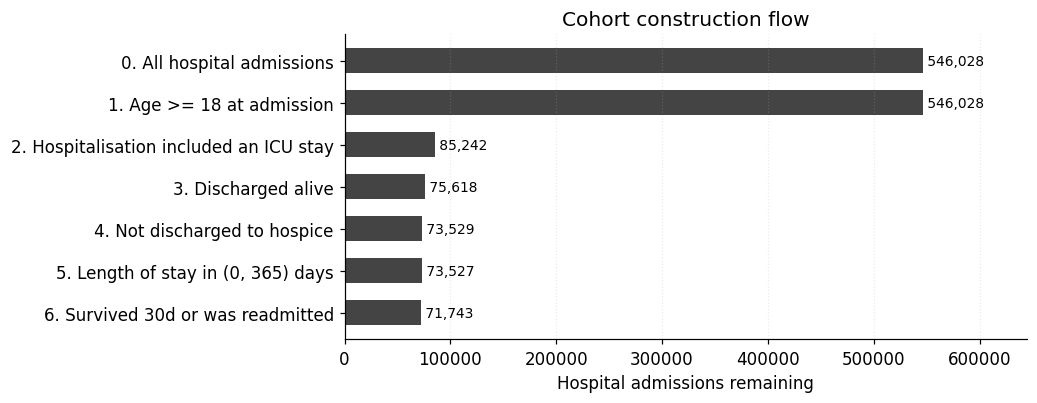

In [15]:
# ----------------------------------------------------------------------------------
# 4.5 The cohort flow table - put this on a slide
# ----------------------------------------------------------------------------------
flow_df = pd.DataFrame(flow).drop_duplicates(subset="step", keep="last").reset_index(drop=True)
flow_df["pct_of_start"] = (flow_df["n_admissions"] / flow_df["n_admissions"].iloc[0] * 100).round(1)
display(flow_df)
flow_df.to_csv(PROJECT_DIR / "cohort_flow.csv", index=False)

# A plain horizontal bar chart of the same information.
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(flow_df["step"][::-1], flow_df["n_admissions"][::-1], color=BAR_COLOR, height=0.6)
for y, v in enumerate(flow_df["n_admissions"][::-1]):
    ax.text(v, y, f" {v:,}", va="center", fontsize=9)
ax.set_xlabel("Hospital admissions remaining")
ax.set_title("Cohort construction flow")
ax.grid(axis="y", visible=False)
ax.margins(x=0.18)
save_fig(fig, "fig01_cohort_flow")
plt.show()

(1) days_to_next for positives: min=0.00, max=30.00  OK
(2) all positive next-admission types are unplanned  OK
(3) outcome rate = 20.12% -- plausible
  saved -> readmission_project/figures/fig02_time_to_readmission.png


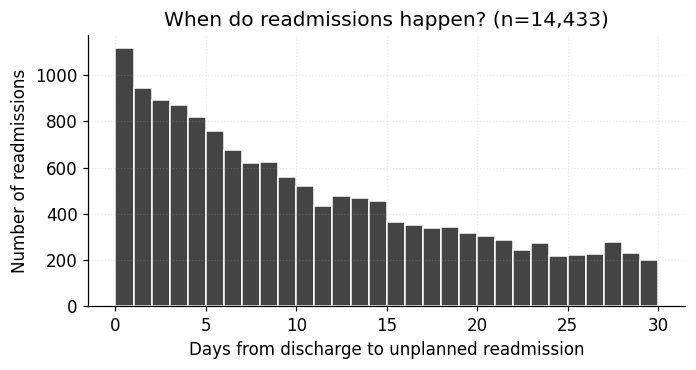

In [16]:
# ----------------------------------------------------------------------------------
# 4.6 Verify the label before trusting it
# ----------------------------------------------------------------------------------
# Three cheap checks that would have caught every label bug I have ever written.

# (1) The distribution of days_to_next among positives must lie inside the window.
pos = cohort[cohort["readmit_30d"] == 1]
assert pos["days_to_next"].between(0, READMIT_WINDOW_DAYS).all(), "positives outside the window!"
print(f"(1) days_to_next for positives: min={pos['days_to_next'].min():.2f}, "
      f"max={pos['days_to_next'].max():.2f}  OK")

# (2) Every positive's next admission type must be in our unplanned set.
assert pos["next_admission_type"].isin(UNPLANNED_TYPES).all()
print("(2) all positive next-admission types are unplanned  OK")

# (3) The outcome rate should be clinically plausible (roughly 5-30% for this population).
rate = cohort["readmit_30d"].mean()
print(f"(3) outcome rate = {rate:.2%} "
      f"{'-- plausible' if 0.03 < rate < 0.35 else '-- SUSPICIOUS, investigate'}")

# Time-to-readmission histogram: readmissions cluster in the first week, which is the
# well-documented pattern and a good sign the label is behaving.
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(pos["days_to_next"], bins=READMIT_WINDOW_DAYS, color=BAR_COLOR, edgecolor="white")
ax.set_xlabel("Days from discharge to unplanned readmission")
ax.set_ylabel("Number of readmissions")
ax.set_title(f"When do readmissions happen? (n={len(pos):,})")
save_fig(fig, "fig02_time_to_readmission")
plt.show()

---
## 5. Feature engineering

### The one rule

> **Every feature must be computable at `dischtime` using only information recorded on or
> before `dischtime`.**

Violating it is called **target leakage**, and it is the reason so many published clinical
models look brilliant in a paper and useless in a hospital. Leakage does not announce itself:
it shows up as an AUROC of 0.95 that you are pleased about.

Three leaks that are easy to write by accident in *this* project:

| Tempting feature | Why it leaks |
|---|---|
| "Number of admissions this patient has" | Counts admissions in the *future* too. A patient with many admissions has them partly *because* they were readmitted. Must be counted strictly before the index admission. |
| "Time until the patient's death" | Uses `dod`, recorded after discharge. |
| "Average length of stay for this patient" | Same problem: averages over future encounters. |

We therefore compute history features with an explicit backward-looking window, and we test
that they never peek forward.

In [17]:
# ----------------------------------------------------------------------------------
# 5.1 Prior-utilisation features (the leakage-sensitive ones)
# ----------------------------------------------------------------------------------
# Strategy: work on the FULL admissions table (so nothing is hidden), sort within patient,
# and use a backward-looking rolling time window.
#
# pandas' `.rolling("365D")` on a datetime index counts every row whose index falls in
# (t - 365 days, t]. That INCLUDES the current row, so we subtract 1 to get "prior".

hist = admissions[["subject_id", "hadm_id", "admittime", "dischtime", "admission_type"]].copy()
hist = hist.sort_values(["subject_id", "admittime"]).reset_index(drop=True)
hist["is_unplanned"] = hist["admission_type"].isin(UNPLANNED_TYPES).astype("int8")
hist["ones"] = 1

indexed = hist.set_index("admittime")

# (a) admissions in the preceding 365 days
rolled_all = indexed.groupby("subject_id")["ones"].rolling("365D").sum()
# (b) *unplanned* admissions in the preceding 365 days
rolled_unp = indexed.groupby("subject_id")["is_unplanned"].rolling("365D").sum()

# groupby preserves within-group order and iterates groups in sorted subject_id order,
# which is exactly the order of `hist`. Assert it rather than hope.
assert len(rolled_all) == len(hist), "rolling result misaligned - do not ignore this"

hist["n_prior_admits_365d"] = rolled_all.to_numpy() - 1
hist["n_prior_unplanned_365d"] = rolled_unp.to_numpy() - hist["is_unplanned"].to_numpy()

# (c) lifetime count of strictly earlier admissions (cumcount is 0 for the first)
hist["n_prior_admits_total"] = hist.groupby("subject_id").cumcount()

# (d) days since the patient's previous discharge (NaN for a first-ever admission)
prev_disch = hist.groupby("subject_id")["dischtime"].shift(1)
hist["days_since_prev_discharge"] = (
    (hist["admittime"] - prev_disch).dt.total_seconds() / 86400.0
)

# (e) a simple flag: has this patient ever been here before?
hist["is_first_admission"] = (hist["n_prior_admits_total"] == 0).astype("int8")

prior_cols = [
    "hadm_id", "n_prior_admits_365d", "n_prior_unplanned_365d",
    "n_prior_admits_total", "days_since_prev_discharge", "is_first_admission",
]
cohort = cohort.merge(hist[prior_cols], on="hadm_id", how="left", validate="one_to_one")

# --- Leakage test -------------------------------------------------------------------
# For a random sample of admissions, recount prior admissions the slow, obviously-correct
# way and confirm the fast version agrees. This is the kind of check that earns trust.
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(cohort), size=min(200, len(cohort)), replace=False)
sample_subjects = set(cohort.iloc[sample_idx]["subject_id"])
sub_adm = admissions[admissions["subject_id"].isin(sample_subjects)]
adm_by_subject = {sid: g["admittime"].to_numpy()
                  for sid, g in sub_adm.groupby("subject_id")}
mismatches = 0
for i in sample_idx:
    row = cohort.iloc[i]
    times = adm_by_subject[row["subject_id"]]
    t = np.datetime64(row["admittime"])
    slow = int(((times < t) & (times > t - np.timedelta64(365, "D"))).sum())
    if slow != int(row["n_prior_admits_365d"]):
        mismatches += 1
print(f"Leakage/correctness test on {len(sample_idx)} sampled admissions: "
      f"{mismatches} mismatches {'-- PASS' if mismatches == 0 else '-- INVESTIGATE'}")

display(cohort[["n_prior_admits_365d", "n_prior_unplanned_365d",
                "n_prior_admits_total", "days_since_prev_discharge"]].describe().round(2))

Leakage/correctness test on 200 sampled admissions: 0 mismatches -- PASS


,n_prior_admits_365d,n_prior_unplanned_365d,n_prior_admits_total,days_since_prev_discharge
count,71743.00,71743.00,71743.00,34063.00
mean,0.92,0.86,2.43,372.44
std,2.09,2.05,6.01,674.64
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,18.14
50%,0.00,0.00,0.00,79.34
75%,1.00,1.00,2.00,392.61
max,57.00,57.00,227.00,5298.83


### 5.2 Comorbidity burden: the Charlson Comorbidity Index

Raw ICD codes are useless as model inputs — there are ~70,000 of them, most appearing a
handful of times. The standard move in health-services research is to collapse them into
validated **comorbidity groups**. We implement the Charlson Comorbidity Index using the
coding algorithm published by Quan et al. (*Medical Care*, 2005), which gives code lists for
both ICD-9-CM and ICD-10 — essential here, because MIMIC-IV spans the U.S. transition
between them and a single hospitalisation can contain either.

The index is a weighted sum of 17 condition groups (weights 1, 2, 3, 6), originally derived to
predict 1-year mortality. Three hierarchy rules avoid double counting:

* diabetes **with** complications supersedes diabetes without,
* severe liver disease supersedes mild,
* metastatic solid tumour supersedes non-metastatic malignancy.

> **Honest scoping note.** What follows is a *faithful but simplified* implementation, written
> to be readable rather than exhaustive: we match on code prefixes, which occasionally
> over-captures a neighbouring code. For publication-grade work, use the validated SQL in the
> [MIMIC code repository](https://github.com/MIT-LCP/mimic-code) (`concepts/comorbidity/charlson.sql`)
> and compare against this. Doing that comparison is a genuinely good exercise.

In [18]:
# ----------------------------------------------------------------------------------
# 5.2 Charlson Comorbidity Index from ICD-9 and ICD-10 codes
# ----------------------------------------------------------------------------------
def icd9_range(lo, hi):
    """Expand an inclusive ICD-9 3-digit range, e.g. 140-172 -> ['140','141',...,'172']."""
    return [f"{i:03d}" for i in range(lo, hi + 1)]


def icd10_range(letter, lo, hi):
    """Expand an inclusive ICD-10 range, e.g. ('C', 0, 26) -> ['C00','C01',...,'C26']."""
    return [f"{letter}{i:02d}" for i in range(lo, hi + 1)]


# Each entry: weight, plus the ICD-9-CM and ICD-10 code prefixes that define the group.
# Prefixes are written at their natural length (3, 4 or 5 characters); the matcher below
# compares each length separately, so mixing lengths is fine.
CHARLSON = {
    "myocardial_infarction": dict(
        weight=1,
        icd9=["410", "412"],
        icd10=["I21", "I22", "I252"]),
    "congestive_heart_failure": dict(
        weight=1,
        icd9=["39891", "40201", "40211", "40291", "40401", "40403", "40411", "40413",
              "40491", "40493", "4254", "4255", "4256", "4257", "4258", "4259", "428"],
        icd10=["I099", "I110", "I130", "I132", "I255", "I420", "I425", "I426", "I427",
               "I428", "I429", "I43", "I50", "P290"]),
    "peripheral_vascular": dict(
        weight=1,
        icd9=["0930", "4373", "440", "441", "4431", "4432", "4433", "4434", "4435",
              "4436", "4437", "4438", "4439", "4471", "5571", "5579", "V434"],
        icd10=["I70", "I71", "I731", "I738", "I739", "I771", "I790", "I792",
               "K551", "K558", "K559", "Z958", "Z959"]),
    "cerebrovascular": dict(
        weight=1,
        icd9=["36234"] + icd9_range(430, 438),
        icd10=["G45", "G46", "H340"] + icd10_range("I", 60, 69)),
    "dementia": dict(
        weight=1,
        icd9=["290", "2941", "3312"],
        icd10=["F00", "F01", "F02", "F03", "F051", "G30", "G311"]),
    "chronic_pulmonary": dict(
        weight=1,
        icd9=["4168", "4169"] + icd9_range(490, 505) + ["5064", "5081", "5088"],
        icd10=["I278", "I279"] + icd10_range("J", 40, 47) + icd10_range("J", 60, 67)
              + ["J684", "J701", "J703"]),
    "rheumatic": dict(
        weight=1,
        icd9=["4465", "7100", "7101", "7102", "7103", "7104",
              "7140", "7141", "7142", "7148", "725"],
        icd10=["M05", "M06", "M315", "M32", "M33", "M34", "M351", "M353", "M360"]),
    "peptic_ulcer": dict(
        weight=1,
        icd9=["531", "532", "533", "534"],
        icd10=["K25", "K26", "K27", "K28"]),
    "mild_liver": dict(
        weight=1,
        icd9=["07022", "07023", "07032", "07033", "07044", "07054", "0706", "0709",
              "570", "571", "5733", "5734", "5738", "5739", "V427"],
        icd10=["B18", "K700", "K701", "K702", "K703", "K709", "K713", "K714", "K715",
               "K717", "K73", "K74", "K760", "K762", "K763", "K764", "K768", "K769",
               "Z944"]),
    "diabetes_uncomplicated": dict(
        weight=1,
        icd9=["2500", "2501", "2502", "2503", "2508", "2509"],
        icd10=["E100", "E101", "E106", "E108", "E109", "E110", "E111", "E116", "E118",
               "E119", "E120", "E121", "E126", "E128", "E129", "E130", "E131", "E136",
               "E138", "E139", "E140", "E141", "E146", "E148", "E149"]),
    "diabetes_complicated": dict(
        weight=2,
        icd9=["2504", "2505", "2506", "2507"],
        icd10=["E102", "E103", "E104", "E105", "E107", "E112", "E113", "E114", "E115",
               "E117", "E122", "E123", "E124", "E125", "E127", "E132", "E133", "E134",
               "E135", "E137", "E142", "E143", "E144", "E145", "E147"]),
    "paralysis": dict(
        weight=2,
        icd9=["3341", "342", "343", "3440", "3441", "3442", "3443", "3444", "3445",
              "3446", "3449"],
        icd10=["G041", "G114", "G801", "G802", "G81", "G82", "G830", "G831", "G832",
               "G833", "G834", "G839"]),
    "renal_disease": dict(
        weight=2,
        icd9=["40301", "40311", "40391", "40402", "40403", "40412", "40413", "40492",
              "40493", "582", "5830", "5831", "5832", "5834", "5836", "5837", "585",
              "586", "5880", "V420", "V451", "V56"],
        icd10=["I120", "I131", "N032", "N033", "N034", "N035", "N036", "N037", "N052",
               "N053", "N054", "N055", "N056", "N057", "N18", "N19", "N250", "Z490",
               "Z491", "Z492", "Z940", "Z992"]),
    "malignancy": dict(
        weight=2,
        icd9=icd9_range(140, 172) + icd9_range(174, 195) + icd9_range(200, 208) + ["2386"],
        icd10=(icd10_range("C", 0, 26) + icd10_range("C", 30, 34) + icd10_range("C", 37, 41)
               + ["C43"] + icd10_range("C", 45, 58) + icd10_range("C", 60, 76)
               + icd10_range("C", 81, 85) + ["C88"] + icd10_range("C", 90, 97))),
    "severe_liver": dict(
        weight=3,
        icd9=["4560", "4561", "4562", "5722", "5723", "5724", "5728"],
        icd10=["I850", "I859", "I864", "I982", "K704", "K711", "K721", "K729",
               "K765", "K766", "K767"]),
    "metastatic_cancer": dict(
        weight=6,
        icd9=["196", "197", "198", "199"],
        icd10=["C77", "C78", "C79", "C80"]),
    "aids_hiv": dict(
        weight=6,
        icd9=["042", "043", "044"],
        icd10=["B20", "B21", "B22", "B24"]),
}


def _by_length(codes):
    """Group a list of prefixes by their character length -> {len: set(prefixes)}."""
    out = {}
    for c in codes:
        out.setdefault(len(c), set()).add(c)
    return out


def _match(series, prefixes_by_len):
    """Boolean mask: does each code start with any prefix in the given set?

    We compare fixed-length slices against a Python set, which is far faster than
    a regex or a chain of str.startswith calls on millions of rows.
    """
    mask = np.zeros(len(series), dtype=bool)
    for length, prefix_set in prefixes_by_len.items():
        mask |= series.str[:length].isin(prefix_set).to_numpy(dtype=bool)
    return pd.Series(mask, index=series.index)


def compute_charlson(dx, hadm_ids):
    """Return one row per hadm_id with 17 comorbidity flags and the Charlson score.

    Parameters
    ----------
    dx : DataFrame with columns [hadm_id, icd_code, icd_version]
    hadm_ids : iterable of hadm_id values to restrict to (the cohort)
    """
    d = dx[dx["hadm_id"].isin(set(hadm_ids))].copy()
    # Normalise: upper case, strip padding whitespace. MIMIC stores ICD-9 without the
    # decimal point already (414.01 -> "41401"), which is what our prefixes assume.
    d["code"] = d["icd_code"].fillna("").astype(str).str.upper().str.strip()
    is9, is10 = d["icd_version"] == 9, d["icd_version"] == 10

    flags = pd.DataFrame({"hadm_id": d["hadm_id"]})
    for name, spec in CHARLSON.items():
        m9 = _match(d["code"], _by_length(spec["icd9"])) & is9
        m10 = _match(d["code"], _by_length(spec["icd10"])) & is10
        flags[name] = (m9 | m10).astype("int8")

    # Collapse the many diagnosis rows per hospitalisation into one row of flags.
    out = flags.groupby("hadm_id").max().reset_index()

    # Hierarchy rules: do not count the milder form when the severe form is present.
    out.loc[out["diabetes_complicated"] == 1, "diabetes_uncomplicated"] = 0
    out.loc[out["severe_liver"] == 1, "mild_liver"] = 0
    out.loc[out["metastatic_cancer"] == 1, "malignancy"] = 0

    out["charlson_score"] = sum(out[n] * s["weight"] for n, s in CHARLSON.items())
    return out


charlson = cached(
    "charlson",
    lambda: compute_charlson(diagnoses, cohort["hadm_id"]),
)

# Total number of coded diagnoses is itself a crude proxy for complexity / coding intensity.
n_dx = (
    diagnoses[diagnoses["hadm_id"].isin(set(cohort["hadm_id"]))]
    .groupby("hadm_id").size().rename("n_diagnoses").reset_index()
)

cohort = cohort.merge(charlson, on="hadm_id", how="left").merge(n_dx, on="hadm_id", how="left")

# Admissions with no coded diagnoses get 0, not NaN - absence of a code means absence of
# a recorded condition, which is the honest interpretation for billing data.
charlson_cols = list(CHARLSON.keys()) + ["charlson_score"]
cohort[charlson_cols + ["n_diagnoses"]] = cohort[charlson_cols + ["n_diagnoses"]].fillna(0)

print(f"Charlson score: mean={cohort['charlson_score'].mean():.2f}, "
      f"median={cohort['charlson_score'].median():.0f}, "
      f"max={cohort['charlson_score'].max():.0f}")
print("\nPrevalence of each comorbidity group, and readmission rate within it:")
summary = pd.DataFrame({
    "prevalence": cohort[list(CHARLSON.keys())].mean(),
    "readmit_rate_if_present": [
        cohort.loc[cohort[c] == 1, "readmit_30d"].mean() for c in CHARLSON
    ],
}).sort_values("prevalence", ascending=False)
display((summary * 100).round(1).rename(columns=lambda c: c + " (%)"))

[cache] building charlson ...
[cache] wrote charlson.parquet in 21.4s
Charlson score: mean=2.59, median=2, max=16

Prevalence of each comorbidity group, and readmission rate within it:


,prevalence (%),readmit_rate_if_present (%)
congestive_heart_failure,25.9,24.6
chronic_pulmonary,24.4,22.6
renal_disease,20.1,27.3
diabetes_uncomplicated,18.9,20.5
cerebrovascular,16.0,15.5
myocardial_infarction,15.8,21.0
peripheral_vascular,11.2,22.5
diabetes_complicated,11.0,26.6
malignancy,7.7,27.2
mild_liver,6.4,26.0


### 5.3 Optional: last laboratory values before discharge

`labevents` is the largest table in the `hosp` module (over 100 million rows). Loading it
whole will exhaust a laptop's memory. The professional pattern is **stream, filter, discard**:
read a chunk, immediately throw away the 99.9% of rows you do not need, keep the remainder,
and move on. We then cache the tiny result so this only ever runs once.

We take the **last recorded value before discharge** for a panel of twelve common analytes.
The last creatinine before discharge, for instance, is a genuinely useful signal: leaving
hospital with a kidney function that has not recovered is a known readmission risk factor.

Set `USE_LABS = False` in the configuration cell to skip this entirely — the rest of the
notebook works without it.

In [19]:
# ----------------------------------------------------------------------------------
# 5.3 Streaming extraction of last-before-discharge lab values
# ----------------------------------------------------------------------------------
# itemids come from hosp/d_labitems.csv.gz. These are the standard MIMIC-IV blood
# chemistry / haematology itemids; verify them against your own copy (we print the
# labels below so you can check).
LAB_ITEMS = {
    50912: "creatinine",
    51006: "bun",
    50983: "sodium",
    50971: "potassium",
    50882: "bicarbonate",
    50868: "anion_gap",
    51222: "hemoglobin",
    51301: "wbc",
    51265: "platelets",
    50931: "glucose",
    50862: "albumin",
    50885: "bilirubin_total",
}

# Confirm the itemids mean what we think they mean. Never trust a hard-coded ID.
d_lab = read_table("d_labitems")
display(d_lab[d_lab["itemid"].isin(LAB_ITEMS)][["itemid", "label", "fluid", "category"]])


def extract_last_labs():
    """Stream labevents and keep the last value before discharge for each (hadm_id, itemid)."""
    wanted_hadm = set(cohort["hadm_id"])
    disch = cohort.set_index("hadm_id")["dischtime"]
    keep = []
    rows_seen = 0
    t0 = time.time()

    for i, chunk in enumerate(iter_table(
        "labevents",
        usecols=["hadm_id", "itemid", "charttime", "valuenum"],
        dtype={"hadm_id": "float64", "itemid": "int32", "valuenum": "float32"},
        parse_dates=["charttime"],
    )):
        rows_seen += len(chunk)
        # Filter hard and early: this is the whole trick.
        chunk = chunk[chunk["itemid"].isin(LAB_ITEMS)]
        chunk = chunk[chunk["hadm_id"].isin(wanted_hadm)]
        chunk = chunk.dropna(subset=["valuenum", "charttime"])
        if len(chunk):
            keep.append(chunk)
        if (i + 1) % 5 == 0:
            print(f"    chunk {i + 1}: {rows_seen:,} rows scanned, "
                  f"{sum(len(k) for k in keep):,} kept, {time.time() - t0:.0f}s")

    labs = pd.concat(keep, ignore_index=True)
    labs["hadm_id"] = labs["hadm_id"].astype("int64")

    # Drop anything charted after discharge (rare, but it would be leakage).
    labs = labs.merge(disch.rename("dischtime"), left_on="hadm_id", right_index=True, how="left")
    labs = labs[labs["charttime"] <= labs["dischtime"]]

    # Last value per hospitalisation per analyte.
    labs = labs.sort_values("charttime")
    last = labs.groupby(["hadm_id", "itemid"])["valuenum"].last().unstack()
    last.columns = [f"last_{LAB_ITEMS[c]}" for c in last.columns]
    return last.reset_index()


if USE_LABS:
    last_labs = cached("last_labs", extract_last_labs)
    cohort = cohort.merge(last_labs, on="hadm_id", how="left")
    # Take the column list from the lab table itself. Do NOT scan cohort.columns for a
    # "last_" prefix: icustays already contributed `last_careunit` and `last_icu_outtime`,
    # and sweeping those into the numeric feature list produces a duplicated-column error
    # several cells later that is genuinely annoying to trace back to here.
    lab_cols = [c for c in last_labs.columns if c != "hadm_id"]
    print(f"\nAdded {len(lab_cols)} lab features.")
    display(cohort[lab_cols].describe().T[["count", "mean", "50%", "std"]].round(2))
    print("\nMissingness is meaningful here: a lab that was never drawn tells you something "
          "about the patient. We impute it later, but we also keep a 'was it measured' flag.")
else:
    lab_cols = []
    print("USE_LABS is False - skipping laboratory features.")

  d_labitems              1,650 rows x  4 cols  (  0.0s)


,itemid,label,fluid,category
60,50862,Albumin,Blood,Chemistry
66,50868,Anion Gap,Blood,Chemistry
80,50882,Bicarbonate,Blood,Chemistry
83,50885,"Bilirubin, Total",Blood,Chemistry
110,50912,Creatinine,Blood,Chemistry
129,50931,Glucose,Blood,Chemistry
168,50971,Potassium,Blood,Chemistry
180,50983,Sodium,Blood,Chemistry
202,51006,Urea Nitrogen,Blood,Chemistry
407,51222,Hemoglobin,Blood,Hematology


[cache] building last_labs ...
    chunk 5: 10,000,000 rows scanned, 575,083 kept, 18s
    chunk 10: 20,000,000 rows scanned, 1,154,026 kept, 35s
    chunk 15: 30,000,000 rows scanned, 1,734,148 kept, 54s
    chunk 20: 40,000,000 rows scanned, 2,283,103 kept, 71s
    chunk 25: 50,000,000 rows scanned, 2,843,784 kept, 89s
    chunk 30: 60,000,000 rows scanned, 3,414,888 kept, 108s
    chunk 35: 70,000,000 rows scanned, 3,991,204 kept, 125s
    chunk 40: 80,000,000 rows scanned, 4,542,555 kept, 143s
    chunk 45: 90,000,000 rows scanned, 5,090,270 kept, 161s
    chunk 50: 100,000,000 rows scanned, 5,657,744 kept, 179s
    chunk 55: 110,000,000 rows scanned, 6,201,748 kept, 197s
    chunk 60: 120,000,000 rows scanned, 6,786,481 kept, 220s
    chunk 65: 130,000,000 rows scanned, 7,360,951 kept, 237s
    chunk 70: 140,000,000 rows scanned, 7,906,898 kept, 255s
    chunk 75: 150,000,000 rows scanned, 8,468,895 kept, 274s
    chunk 80: 158,374,764 rows scanned, 8,947,575 kept, 290s
[cache] wr

,count,mean,50%,std
last_albumin,37734.0,3.27,3.3,0.64
last_anion_gap,71211.0,12.90,13.0,2.96
last_bicarbonate,71212.0,26.36,26.0,3.89
last_bilirubin_total,44849.0,0.84,0.5,1.62
last_creatinine,71227.0,1.19,0.8,1.28
last_glucose,71210.0,117.19,106.0,41.94
last_potassium,71223.0,4.11,4.1,0.46
last_sodium,71220.0,138.56,139.0,3.61
last_bun,71223.0,20.91,17.0,15.47
last_hemoglobin,71187.0,10.45,10.2,1.96



Missingness is meaningful here: a lab that was never drawn tells you something about the patient. We impute it later, but we also keep a 'was it measured' flag.


In [20]:
# ----------------------------------------------------------------------------------
# 5.4 Optional: polypharmacy (number of distinct drugs ordered during the stay)
# ----------------------------------------------------------------------------------
# Patients leaving on many medications are at higher risk of drug interactions, confusion
# about the regimen, and non-adherence - all classic readmission drivers.
def extract_drug_counts():
    wanted = set(cohort["hadm_id"])
    parts = []
    for chunk in iter_table(
        "prescriptions",
        usecols=["hadm_id", "drug"],
        dtype={"hadm_id": "float64", "drug": "string"},
    ):
        chunk = chunk[chunk["hadm_id"].isin(wanted)]
        if len(chunk):
            parts.append(chunk.drop_duplicates())
    rx = pd.concat(parts, ignore_index=True).drop_duplicates()
    rx["hadm_id"] = rx["hadm_id"].astype("int64")
    return rx.groupby("hadm_id").size().rename("n_distinct_drugs").reset_index()


if USE_PRESCRIPTIONS:
    drug_counts = cached("drug_counts", extract_drug_counts)
    cohort = cohort.merge(drug_counts, on="hadm_id", how="left")
    cohort["n_distinct_drugs"] = cohort["n_distinct_drugs"].fillna(0)
    rx_cols = ["n_distinct_drugs"]
    print(f"Polypharmacy: median {cohort['n_distinct_drugs'].median():.0f} distinct drugs, "
          f"90th pct {cohort['n_distinct_drugs'].quantile(0.9):.0f}")
else:
    rx_cols = []
    print("USE_PRESCRIPTIONS is False - skipping medication features.")

[cache] building drug_counts ...
[cache] wrote drug_counts.parquet in 48.0s
Polypharmacy: median 36 distinct drugs, 90th pct 63


In [21]:
# ----------------------------------------------------------------------------------
# 5.5 Assemble the modelling table
# ----------------------------------------------------------------------------------
# We declare the feature lists explicitly. Resist the urge to write
# `X = cohort.drop(columns=["readmit_30d"])` - that is how `days_to_next` ends up in your
# model and how you end up with an AUROC of 1.00 and a bad afternoon.

NUMERIC_FEATURES = [
    # demographics & index stay
    "age", "los_days", "ed_los_hours", "came_via_ed",
    # ICU exposure
    "n_icu_stays", "icu_los_days", "icu_los_max",
    # comorbidity
    "charlson_score", "n_diagnoses",
    # prior utilisation (backward-looking only)
    "n_prior_admits_365d", "n_prior_unplanned_365d", "n_prior_admits_total",
    "days_since_prev_discharge", "is_first_admission",
] + list(CHARLSON.keys()) + lab_cols + rx_cols

CATEGORICAL_FEATURES = [
    "gender", "admission_type", "admission_location", "discharge_location",
    "insurance", "marital_status", "first_careunit", "last_careunit",
]

# `race` is deliberately *not* a model input by default. It stays in the dataframe because we
# need it in Section 11 to audit whether the model performs unevenly across groups. Section 11
# explains the reasoning; it is a judgement call, not a settled question.
if USE_RACE_AS_FEATURE:
    CATEGORICAL_FEATURES = CATEGORICAL_FEATURES + ["race"]

TARGET = "readmit_30d"
GROUP = "subject_id"   # used to keep a patient's admissions together when splitting

# Columns that MUST NEVER reach the model. Listing them makes the intent explicit and gives
# us something to assert against.
FORBIDDEN = [
    "next_hadm_id", "next_admittime", "next_admission_type", "days_to_next",
    "dod", "days_to_death", "died_within_window", "deathtime", "hospital_expire_flag",
    "dischtime", "admittime", "edregtime", "edouttime",
]

model_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES
missing = [c for c in model_cols if c not in cohort.columns]
assert not missing, f"These declared features are not in the cohort: {missing}"
assert not set(model_cols) & set(FORBIDDEN), "A forbidden column reached the feature list!"

extra_cols = [c for c in [TARGET, GROUP, "race", "anchor_year_group"] if c not in model_cols]
data = cohort[model_cols + extra_cols].copy()

print(f"Modelling table: {data.shape[0]:,} rows x {len(model_cols)} features "
      f"({len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical)")
print(f"Positive class: {data[TARGET].mean():.2%}")
# The modelling table is ROW-LEVEL patient data, so it is saved in CACHE_DIR with the other
# intermediate files: useful for debugging on your own machine, never to be shared or
# committed (the repository's .gitignore excludes the whole readmission_project/ folder).
data.to_csv(CACHE_DIR / "modelling_table.csv", index=False)


# A feature dictionary instead of `data.head()`: what each input is, how complete it is, and
# a typical value - everything a reader needs, with no patient rows in the output.
def typical_value(col):
    s = data[col]
    if not s.notna().any():
        return "all missing"
    if col in NUMERIC_FEATURES:
        return f"median {s.median():.2f}"
    return f"{s.nunique()} levels; most common: {s.mode(dropna=True).iloc[0]}"


feature_dictionary = pd.DataFrame({
    "kind": ["numeric"] * len(NUMERIC_FEATURES) + ["categorical"] * len(CATEGORICAL_FEATURES),
    "missing_%": (data[model_cols].isna().mean() * 100).round(1).to_numpy(),
    "typical_value": [typical_value(c) for c in model_cols],
}, index=pd.Index(model_cols, name="feature"))
display(feature_dictionary)

Modelling table: 71,743 rows x 52 features (44 numeric, 8 categorical)
Positive class: 20.12%


,kind,missing_%,typical_value
feature,,,
age,numeric,0.0,median 65.00
los_days,numeric,0.0,median 6.76
ed_los_hours,numeric,36.0,median 5.23
came_via_ed,numeric,0.0,median 1.00
n_icu_stays,numeric,0.0,median 1.00
icu_los_days,numeric,0.0,median 1.95
icu_los_max,numeric,0.0,median 1.92
charlson_score,numeric,0.0,median 2.00
n_diagnoses,numeric,0.0,median 16.00


---
## 6. Exploratory analysis

Look at the data before you model it. Three questions worth answering every single time:

1. **How imbalanced is the outcome?** It determines which metrics are meaningful.
2. **What is missing, and is the missingness random?** In an EHR, a lab that was not ordered
   is a decision, not an accident.
3. **Do the obvious risk factors move in the expected direction?** If prior admissions do not
   predict readmission, something is wrong with your pipeline, not with medicine.

Columns with missing values (%):


,percent_missing
days_since_prev_discharge,52.5
last_albumin,47.4
last_bilirubin_total,37.5
ed_los_hours,36.0
marital_status,7.1
insurance,1.5
discharge_location,1.0
last_hemoglobin,0.8
last_platelets,0.8
last_wbc,0.8


  saved -> readmission_project/figures/fig03_missingness.png


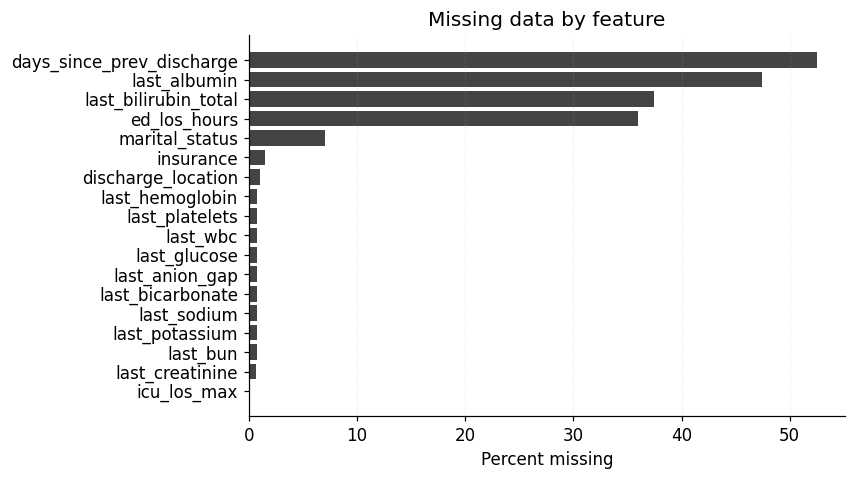

In [22]:
# ----------------------------------------------------------------------------------
# 6.1 Missingness
# ----------------------------------------------------------------------------------
miss = (data[model_cols].isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
print("Columns with missing values (%):")
display(miss.round(1).to_frame("percent_missing"))

if len(miss):
    fig, ax = plt.subplots(figsize=(7, max(2.5, 0.25 * len(miss))))
    ax.barh(miss.index[::-1], miss.values[::-1], color=BAR_COLOR)
    ax.set_xlabel("Percent missing")
    ax.set_title("Missing data by feature")
    ax.grid(axis="y", visible=False)
    save_fig(fig, "fig03_missingness")
    plt.show()

In [23]:
# ----------------------------------------------------------------------------------
# 6.2 Does the outcome vary the way clinical intuition says it should?
# ----------------------------------------------------------------------------------
def rate_by(col, bins=None, labels=None, top=None):
    """Readmission rate and group size for a categorical or binned numeric column."""
    s = data[col]
    if bins is not None:
        s = pd.cut(s, bins=bins, labels=labels, include_lowest=True)
    elif top is not None:
        keep = s.value_counts().head(top).index
        s = s.where(s.isin(keep), other="(other)")
    out = data.groupby(s, observed=True)[TARGET].agg(["mean", "size"])
    out.columns = ["readmit_rate", "n"]
    return out.sort_values("readmit_rate", ascending=False)


print("--- By number of prior unplanned admissions in the past year ---")
display(rate_by("n_prior_unplanned_365d",
                bins=[-0.1, 0, 1, 2, 5, 1000],
                labels=["0", "1", "2", "3-5", "6+"]).round(3))

print("--- By Charlson score band ---")
display(rate_by("charlson_score",
                bins=[-0.1, 0, 2, 4, 6, 100],
                labels=["0", "1-2", "3-4", "5-6", "7+"]).round(3))

print("--- By discharge destination (top 8) ---")
display(rate_by("discharge_location", top=8).round(3))

print("--- By age band ---")
display(rate_by("age", bins=[17, 40, 55, 70, 85, 120],
                labels=["18-39", "40-54", "55-69", "70-84", "85+"]).round(3))

--- By number of prior unplanned admissions in the past year ---


,readmit_rate,n
n_prior_unplanned_365d,,
6+,0.551,2391
3-5,0.389,5175
2,0.291,4830
1,0.232,11225
0,0.147,48122


--- By Charlson score band ---


,readmit_rate,n
charlson_score,,
7+,0.321,4847
5-6,0.278,9053
3-4,0.225,16980
1-2,0.168,27408
0,0.144,13455


--- By discharge destination (top 8) ---


,readmit_rate,n
discharge_location,,
PSYCH FACILITY,0.554,888
AGAINST ADVICE,0.324,793
CHRONIC/LONG TERM ACUTE CARE,0.297,4549
SKILLED NURSING FACILITY,0.233,13839
HOME HEALTH CARE,0.210,21929
REHAB,0.181,6766
(other),0.152,1166
HOME,0.143,21148
ACUTE HOSPITAL,0.129,665


--- By age band ---


,readmit_rate,n
age,,
70-84,0.206,20560
40-54,0.203,12669
55-69,0.200,24484
85+,0.196,6033
18-39,0.193,7997


  saved -> readmission_project/figures/fig04_risk_factors.png


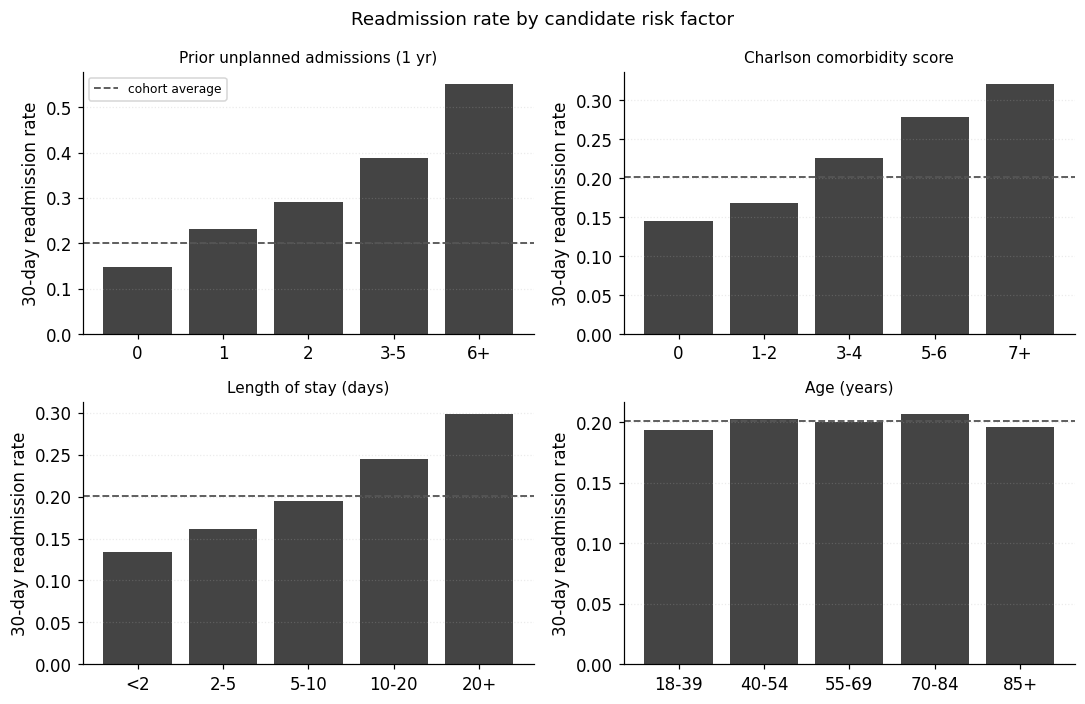

In [24]:
# ----------------------------------------------------------------------------------
# 6.3 One figure that summarises the signal
# ----------------------------------------------------------------------------------
panels = [
    ("n_prior_unplanned_365d", [-0.1, 0, 1, 2, 5, 1000], ["0", "1", "2", "3-5", "6+"],
     "Prior unplanned admissions (1 yr)"),
    ("charlson_score", [-0.1, 0, 2, 4, 6, 100], ["0", "1-2", "3-4", "5-6", "7+"],
     "Charlson comorbidity score"),
    ("los_days", [0, 2, 5, 10, 20, 400], ["<2", "2-5", "5-10", "10-20", "20+"],
     "Length of stay (days)"),
    ("age", [17, 40, 55, 70, 85, 120], ["18-39", "40-54", "55-69", "70-84", "85+"],
     "Age (years)"),
]
fig, axes = plt.subplots(2, 2, figsize=(10, 6.5))
baseline = data[TARGET].mean()
for ax, (col, bins, labels, title) in zip(axes.ravel(), panels):
    tab = data.groupby(pd.cut(data[col], bins=bins, labels=labels, include_lowest=True),
                       observed=True)[TARGET].mean()
    ax.bar(tab.index.astype(str), tab.values, color=BAR_COLOR)
    ax.axhline(baseline, label="cohort average", linewidth=1.2, **style(1))
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("30-day readmission rate")
    ax.grid(axis="x", visible=False)
axes[0, 0].legend(fontsize=8, loc="upper left")
fig.suptitle("Readmission rate by candidate risk factor", fontsize=12)
fig.tight_layout()
save_fig(fig, "fig04_risk_factors")
plt.show()

---
## 7. Splitting the data — by patient, not by row

This is the second place tutorials go wrong.

A patient can contribute several hospitalisations. A random row-wise split will put some of
Mrs Nguyen's admissions in train and others in test. The model then learns *her specifically*
— her baseline creatinine, her usual length of stay — and gets rewarded for it at test time.
The reported AUROC is inflated by an amount you cannot estimate after the fact.

The fix is a **group-aware split**: every row belonging to one `subject_id` goes to exactly
one side. `StratifiedGroupKFold` does this while also keeping the outcome rate roughly equal
across folds.

```
  Row-wise split (WRONG)            Group-wise split (RIGHT)
  patient A: [train][test]          patient A: [train][train]
  patient B: [test][train]          patient B: [test ][test ]
             ^ leak                            ^ no overlap
```

We also build a **temporal split** (Section 12): train on the earliest `anchor_year_group`s
and test on the latest. A random split answers "does this work on patients like these?";
a temporal split answers "will this still work next year?" — which is the question that
actually matters for deployment.

In [25]:
# ----------------------------------------------------------------------------------
# 7.1 Group-aware train / test split
# ----------------------------------------------------------------------------------
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
train_idx, test_idx = next(splitter.split(data, data[TARGET], groups=data[GROUP]))

train = data.iloc[train_idx].reset_index(drop=True)
test = data.iloc[test_idx].reset_index(drop=True)

X_train, y_train, g_train = train[model_cols], train[TARGET], train[GROUP]
X_test, y_test = test[model_cols], test[TARGET]

print(f"Train: {len(train):>7,} admissions  {train[GROUP].nunique():>7,} patients  "
      f"{y_train.mean():.2%} positive")
print(f"Test : {len(test):>7,} admissions  {test[GROUP].nunique():>7,} patients  "
      f"{y_test.mean():.2%} positive")

# The check that makes the split trustworthy: zero shared patients.
overlap = set(train[GROUP]) & set(test[GROUP])
assert not overlap, f"{len(overlap)} patients appear in BOTH splits - the split is broken"
print(f"\nPatient overlap between train and test: {len(overlap)}  OK")

# For reference, how much would a naive row-wise split have leaked?
naive_train, naive_test = np.split(
    np.random.default_rng(0).permutation(len(data)), [int(0.8 * len(data))])
naive_overlap = (set(data.iloc[naive_train][GROUP]) & set(data.iloc[naive_test][GROUP]))
print(f"A naive row-wise split would have shared {len(naive_overlap):,} patients "
      f"({len(naive_overlap) / data[GROUP].nunique():.1%} of all patients) across the split.")

Train:  57,417 admissions   44,393 patients  20.10% positive
Test :  14,326 admissions   11,099 patients  20.18% positive

Patient overlap between train and test: 0  OK
A naive row-wise split would have shared 3,789 patients (6.8% of all patients) across the split.


In [26]:
# ----------------------------------------------------------------------------------
# 7.2 Preprocessing pipeline
# ----------------------------------------------------------------------------------
# Everything that *learns* from data (the median used for imputation, the scaler's mean and
# standard deviation, the set of one-hot categories) must be fitted on the TRAINING data only.
# Wrapping it all in an sklearn Pipeline is not a stylistic preference - it is what makes that
# guarantee automatic when you cross-validate.
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


def make_ohe():
    """OneHotEncoder with a cross-version-compatible sparse argument."""
    try:                                  # scikit-learn >= 1.2
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False, min_frequency=20)
    except TypeError:                     # older scikit-learn
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(scale=True):
    """Numeric: median-impute (+ optionally scale). Categorical: mode-impute + one-hot.

    `scale=False` is used for the tree ensembles, which do not care about feature scale.
    """
    numeric_steps = [("impute", SimpleImputer(strategy="median", add_indicator=True))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), NUMERIC_FEATURES),
            ("cat", Pipeline([
                ("impute", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_ohe()),
            ]), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# `add_indicator=True` above is a small but important choice: for every numeric column with
# missing values it appends a binary "was this missing?" column. In an EHR, the fact that a
# test was never ordered carries information, and this lets the model use it.

demo = build_preprocessor().fit(X_train)
print(f"Feature matrix after preprocessing: {demo.transform(X_train.head(5)).shape[1]} columns")
print("First 12 expanded feature names:")
print(list(demo.get_feature_names_out()[:12]))

Feature matrix after preprocessing: 125 columns
First 12 expanded feature names:
['age', 'los_days', 'ed_los_hours', 'came_via_ed', 'n_icu_stays', 'icu_los_days', 'icu_los_max', 'charlson_score', 'n_diagnoses', 'n_prior_admits_365d', 'n_prior_unplanned_365d', 'n_prior_admits_total']


---
## 8. Models

Four families, chosen because each teaches something different.

| Model | Why it is here | What to watch |
|---|---|---|
| **Penalised logistic regression** | The baseline you must beat. Coefficients are odds ratios a clinician can read and argue with. | If a fancy model cannot beat it, use it. |
| **Random forest** | Bagged trees; captures interactions with almost no tuning. | Probabilities are poorly calibrated out of the box. |
| **Histogram gradient boosting** | Usually the strongest model on tabular EHR data. | Easy to overfit; watch the CV/test gap. |
| **Multi-layer perceptron** | The deep-learning family member. Shows what a small neural net does — and does not do — on tabular data of this size. | Needs scaled inputs; rarely wins on tabular data. |

> **An honest expectation.** On structured readmission data, published AUROCs sit around
> **0.65–0.72**. If you get 0.95, you have a leak. A modest AUROC is not a failed project —
> readmission is driven substantially by housing, transport, social support, and follow-up
> access, none of which appear anywhere in MIMIC.

In [27]:
# ----------------------------------------------------------------------------------
# 8.1 Define the models
# ----------------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

models = {
    # L2-penalised logistic regression. We leave class_weight=None on purpose. The popular
    # alternative, class_weight="balanced", up-weights the rarer positive class: that barely
    # changes the *ranking* (so AUROC is similar), but it inflates every predicted probability,
    # i.e. it deliberately breaks calibration (Section 9.3). Keeping the model unweighted and
    # choosing a threshold that matches the care team's capacity (Section 9.4) is the cleaner
    # way to deal with class imbalance here.
    "Logistic regression": Pipeline([
        ("pre", build_preprocessor(scale=True)),
        ("clf", LogisticRegression(
            penalty="l2", C=1.0, max_iter=3000, solver="lbfgs",
            class_weight=None, random_state=RANDOM_SEED)),
    ]),

    # Random forest. min_samples_leaf is the main guard against memorising single patients.
    "Random forest": Pipeline([
        ("pre", build_preprocessor(scale=False)),
        ("clf", RandomForestClassifier(
            n_estimators=400, min_samples_leaf=20, max_features="sqrt",
            n_jobs=-1, random_state=RANDOM_SEED)),
    ]),

    # Histogram gradient boosting: fast, handles missing values natively, strong default.
    "Gradient boosting": Pipeline([
        ("pre", build_preprocessor(scale=False)),
        ("clf", HistGradientBoostingClassifier(
            max_iter=400, learning_rate=0.06, max_leaf_nodes=31,
            min_samples_leaf=40, l2_regularization=1.0,
            early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_SEED)),
    ]),

    # A small feed-forward network. Two hidden layers is plenty for ~100 tabular features;
    # early_stopping holds out 10% of the training data to decide when to stop.
    "Neural net (MLP)": Pipeline([
        ("pre", build_preprocessor(scale=True)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(64, 32), activation="relu", alpha=1e-3,
            batch_size=512, learning_rate_init=1e-3, max_iter=80,
            early_stopping=True, n_iter_no_change=8, random_state=RANDOM_SEED)),
    ]),
}

# Optional: add a boosted-tree library if it happens to be installed.
try:
    from xgboost import XGBClassifier
    models["XGBoost (optional)"] = Pipeline([
        ("pre", build_preprocessor(scale=False)),
        ("clf", XGBClassifier(
            n_estimators=500, learning_rate=0.05, max_depth=5, subsample=0.8,
            colsample_bytree=0.8, reg_lambda=1.0, eval_metric="logloss",
            tree_method="hist", random_state=RANDOM_SEED)),
    ])
    print("xgboost found - added to the comparison.")
except ImportError:
    print("xgboost not installed - skipping (this is fine).")

print(f"\n{len(models)} models to compare.")

xgboost not installed - skipping (this is fine).

4 models to compare.


In [28]:
# ----------------------------------------------------------------------------------
# 8.2 Cross-validate on the training set
# ----------------------------------------------------------------------------------
# We use StratifiedGroupKFold so that (a) no patient spans folds and (b) each fold has a
# similar outcome rate. Scoring on BOTH AUROC and average precision (AUPRC) from the start
# stops you from falling in love with a number that ignores class imbalance.
from sklearn.model_selection import cross_validate

cv = StratifiedGroupKFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

cv_rows = []
for name, pipe in models.items():
    t0 = time.time()
    scores = cross_validate(
        pipe, X_train, y_train, groups=g_train, cv=cv,
        scoring=["roc_auc", "average_precision"],
        n_jobs=1, error_score="raise",
    )
    cv_rows.append({
        "model": name,
        "cv_auroc": scores["test_roc_auc"].mean(),
        "cv_auroc_sd": scores["test_roc_auc"].std(),
        "cv_auprc": scores["test_average_precision"].mean(),
        "cv_auprc_sd": scores["test_average_precision"].std(),
        "fit_seconds": time.time() - t0,
    })
    print(f"{name:<22} AUROC {cv_rows[-1]['cv_auroc']:.3f} "
          f"(+/-{cv_rows[-1]['cv_auroc_sd']:.3f})   "
          f"AUPRC {cv_rows[-1]['cv_auprc']:.3f}   "
          f"[{cv_rows[-1]['fit_seconds']:.0f}s]")

cv_results = pd.DataFrame(cv_rows).sort_values("cv_auroc", ascending=False)
display(cv_results.round(3))

Logistic regression    AUROC 0.713 (+/-0.004)   AUPRC 0.404   [25s]
Random forest          AUROC 0.717 (+/-0.004)   AUPRC 0.406   [100s]
Gradient boosting      AUROC 0.718 (+/-0.003)   AUPRC 0.412   [36s]
Neural net (MLP)       AUROC 0.709 (+/-0.005)   AUPRC 0.394   [31s]


,model,cv_auroc,cv_auroc_sd,cv_auprc,cv_auprc_sd,fit_seconds
2,Gradient boosting,0.718,0.003,0.412,0.007,36.009
1,Random forest,0.717,0.004,0.406,0.009,99.680
0,Logistic regression,0.713,0.004,0.404,0.008,24.689
3,Neural net (MLP),0.709,0.005,0.394,0.009,30.550


In [29]:
# ----------------------------------------------------------------------------------
# 8.3 Fit each model on the full training set and score the held-out test set
# ----------------------------------------------------------------------------------
fitted, test_probs = {}, {}
for name, pipe in models.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    # predict_proba returns [P(class 0), P(class 1)]; we want column 1.
    test_probs[name] = pipe.predict_proba(X_test)[:, 1]
    print(f"fitted {name:<22} in {time.time() - t0:5.1f}s")

fitted Logistic regression    in   2.5s
fitted Random forest          in  27.2s
fitted Gradient boosting      in   7.4s
fitted Neural net (MLP)       in   6.4s


---
## 9. Evaluation — and why AUROC alone will mislead you

With roughly one admission in five readmitted (in the default 30-day setup), accuracy is close to
worthless: predicting "nobody is readmitted" already scores about 80%. We report four things, each
answering a different question.

| Metric | Question it answers | Baseline to compare against |
|---|---|---|
| **AUROC** | If I pick one readmitted and one non-readmitted patient at random, how often does the model rank them correctly? | 0.5 (coin flip) |
| **AUPRC** (average precision) | Among the patients I flag, how many are real? Sensitive to imbalance, unlike AUROC. | the prevalence (≈ 0.20 here) |
| **Brier score** | Are the *probabilities themselves* right, not just their order? Lower is better. | prevalence × (1 − prevalence) |
| **Operating-point metrics** | If the nurse can call 10% of dischargees, how many real readmissions do we catch, and how many calls are wasted? | — |

The last row is the one clinicians care about. A model is not deployed as an AUROC; it is
deployed as a threshold, a worklist, and a finite number of staff hours.

In [30]:
# ----------------------------------------------------------------------------------
# 9.1 Metric helpers
# ----------------------------------------------------------------------------------
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, roc_curve,
    precision_recall_curve, confusion_matrix, log_loss,
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

ALERT_RATE = 0.10   # the fraction of discharges a care team can realistically follow up


def threshold_for_alert_rate(probs, rate=ALERT_RATE):
    """The probability cut-off that flags exactly `rate` of patients (the highest-risk ones)."""
    return float(np.quantile(probs, 1 - rate))


def evaluate(y_true, probs, alert_rate=ALERT_RATE):
    """Return a dictionary of discrimination, calibration and operating-point metrics."""
    y_true = np.asarray(y_true)
    thr = threshold_for_alert_rate(probs, alert_rate)
    pred = (probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else np.nan       # recall / true positive rate
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan        # precision
    prevalence = y_true.mean()

    return {
        "auroc": roc_auc_score(y_true, probs),
        "auprc": average_precision_score(y_true, probs),
        "brier": brier_score_loss(y_true, probs),
        "log_loss": log_loss(y_true, np.clip(probs, 1e-6, 1 - 1e-6)),
        "prevalence": prevalence,
        "threshold": thr,
        "alert_rate": pred.mean(),
        "sensitivity": sens,
        "specificity": spec,
        "ppv": ppv,
        # Number Needed to Evaluate: how many patients must be followed up to catch one
        # true readmission. The single most intuitive number for a clinical audience.
        "nne": 1 / ppv if ppv and ppv > 0 else np.nan,
        # Lift: how much better than flagging patients at random.
        "lift": ppv / prevalence if prevalence > 0 else np.nan,
    }


results = pd.DataFrame(
    {name: evaluate(y_test, p) for name, p in test_probs.items()}
).T.sort_values("auroc", ascending=False)

print(f"Held-out test set: {len(y_test):,} admissions, "
      f"{y_test.mean():.2%} readmitted within {READMIT_WINDOW_DAYS} days")
print(f"Operating point: flag the top {ALERT_RATE:.0%} of predicted risk\n")
display(results.round(3))

# Add the CV results side by side - a large train/test gap signals overfitting.
comparison = cv_results.set_index("model")[["cv_auroc", "cv_auprc"]].join(
    results[["auroc", "auprc"]].rename(columns={"auroc": "test_auroc", "auprc": "test_auprc"})
)
comparison["auroc_gap"] = comparison["cv_auroc"] - comparison["test_auroc"]
print("\nCross-validation vs held-out test (a large positive gap = overfitting):")
display(comparison.round(3))

# Which model do we carry forward? We decide with CROSS-VALIDATION, not with the test set.
# Picking the winner by test AUROC would quietly turn the test set into a validation set,
# and every number reported from here on would be optimistically biased. The test set is
# for measuring the choice, not for making it.
BEST_MODEL = cv_results.iloc[0]["model"]
print(f"\nModel carried forward (best cross-validated AUROC): {BEST_MODEL}")
if cv_results["cv_auroc"].isna().all():
    print("[!] Cross-validated AUROC is undefined (some folds contain no readmissions), so the "
          "first model in the list was carried forward.\n    This only happens on tiny extracts "
          "such as the 100-patient MIMIC-IV demo: treat every number below as a smoke test.")
if results.index[0] != BEST_MODEL:
    print(f"(The test set happens to rank {results.index[0]} first. We keep the model chosen "
          "before looking at the test set - that is the whole point of holding it out.)")

Held-out test set: 14,326 admissions, 20.18% readmitted within 30 days
Operating point: flag the top 10% of predicted risk



,auroc,auprc,brier,log_loss,prevalence,threshold,alert_rate,sensitivity,specificity,ppv,nne,lift
Gradient boosting,0.704,0.408,0.144,0.456,0.202,0.397,0.1,0.245,0.937,0.495,2.021,2.452
Random forest,0.702,0.402,0.145,0.458,0.202,0.371,0.1,0.245,0.937,0.495,2.021,2.452
Logistic regression,0.701,0.405,0.145,0.458,0.202,0.385,0.1,0.243,0.936,0.490,2.041,2.428
Neural net (MLP),0.699,0.393,0.147,0.464,0.202,0.419,0.1,0.242,0.936,0.488,2.050,2.417



Cross-validation vs held-out test (a large positive gap = overfitting):


,cv_auroc,cv_auprc,test_auroc,test_auprc,auroc_gap
model,,,,,
Gradient boosting,0.718,0.412,0.704,0.408,0.013
Random forest,0.717,0.406,0.702,0.402,0.015
Logistic regression,0.713,0.404,0.701,0.405,0.012
Neural net (MLP),0.709,0.394,0.699,0.393,0.010



Model carried forward (best cross-validated AUROC): Gradient boosting


  saved -> readmission_project/figures/fig05_roc_pr.png


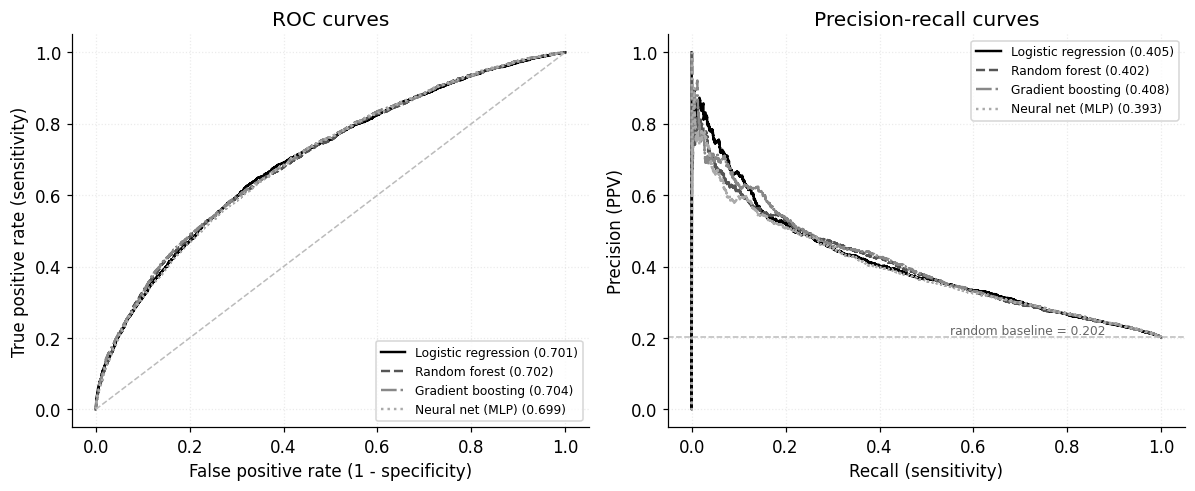

In [31]:
# ----------------------------------------------------------------------------------
# 9.2 ROC and precision-recall curves
# ----------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

# --- ROC ---------------------------------------------------------------------------
ax = axes[0]
for i, (name, probs) in enumerate(test_probs.items()):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} ({results.loc[name, 'auroc']:.3f})",
            linewidth=1.6, **style(i))
ax.plot([0, 1], [0, 1], color="#bbbbbb", linewidth=1, linestyle="--")
ax.set_xlabel("False positive rate (1 - specificity)")
ax.set_ylabel("True positive rate (sensitivity)")
ax.set_title("ROC curves")
ax.legend(fontsize=8, loc="lower right")

# --- Precision-recall ---------------------------------------------------------------
# The dashed horizontal line is the prevalence: what precision you would get by flagging
# patients at random. On an imbalanced problem this is the only honest reference line.
ax = axes[1]
for i, (name, probs) in enumerate(test_probs.items()):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ax.plot(rec, prec, label=f"{name} ({results.loc[name, 'auprc']:.3f})",
            linewidth=1.6, **style(i))
ax.axhline(y_test.mean(), color="#bbbbbb", linewidth=1, linestyle="--")
ax.text(0.55, y_test.mean() + 0.008, f"random baseline = {y_test.mean():.3f}", fontsize=8,
        color="#666666")
ax.set_xlabel("Recall (sensitivity)")
ax.set_ylabel("Precision (PPV)")
ax.set_title("Precision-recall curves")
ax.legend(fontsize=8, loc="upper right")

fig.tight_layout()
save_fig(fig, "fig05_roc_pr")
plt.show()

### 9.3 Calibration: are the probabilities honest?

A model can rank patients perfectly and still be badly wrong about the numbers. If it says
"35% risk" for a group of patients and only 12% of them are readmitted, then any clinician who
acts on the number — and any cost calculation built on it — is being misled.

A **calibration plot** bins patients by predicted risk and plots observed vs predicted. Perfect
calibration is the 45° line. Tree ensembles and random forests are usually *under-confident in
the tails*; neural nets are often *over-confident*.

The fix is **post-hoc recalibration**: fit a small monotone function (isotonic regression, or
Platt scaling) that maps raw scores onto honest probabilities, using cross-validation inside
the training set. It leaves the ranking — and therefore the AUROC — essentially untouched, and it
improves the Brier score *when there is miscalibration to fix*. Logistic regression and gradient
boosting trained on log-loss without class weights are often close to calibrated already; if
recalibration changes almost nothing, that is a finding worth reporting, not a failure.

  saved -> readmission_project/figures/fig06_calibration.png


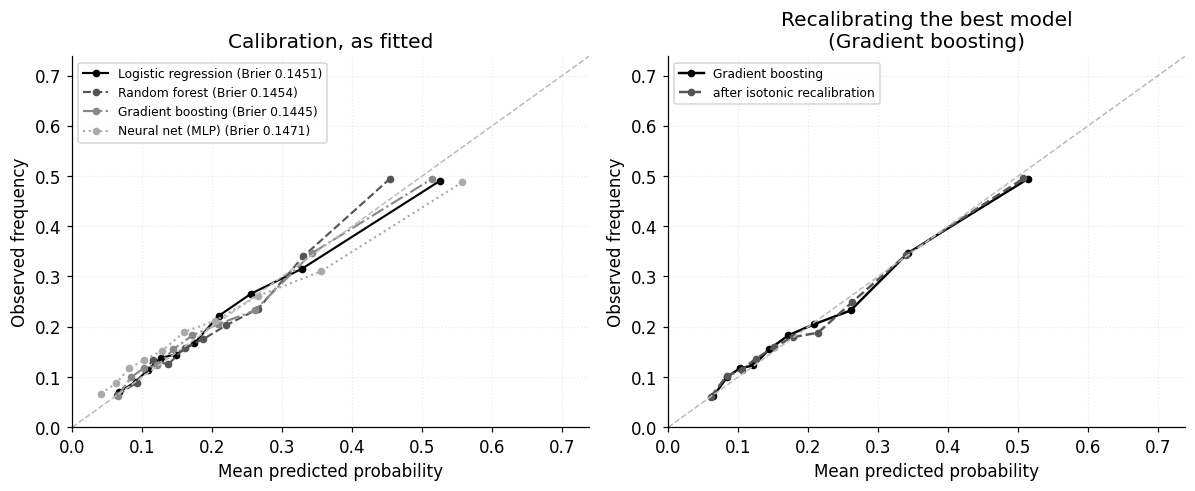

Gradient boosting                Brier 0.1445  AUROC 0.704
+ isotonic recalibration         Brier 0.1446  AUROC 0.704

Change after recalibration: Brier +0.0001, AUROC -0.001
Recalibration changed almost nothing, because this model was already close to calibrated - compare its curve with the 45-degree line in the left panel. That is a useful result: the raw probabilities can be reported as they are.


In [32]:
# ----------------------------------------------------------------------------------
# 9.3 Calibration curves, before and after recalibration
# ----------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

ax = axes[0]
for i, (name, probs) in enumerate(test_probs.items()):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=4,
            label=f"{name} (Brier {results.loc[name, 'brier']:.4f})", linewidth=1.4, **style(i))
ax.plot([0, 1], [0, 1], color="#bbbbbb", linestyle="--", linewidth=1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Calibration, as fitted")
ax.legend(fontsize=8, loc="upper left")
lim = max(0.35, min(1.0, float(np.percentile(np.concatenate(list(test_probs.values())), 99.5))))
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

# --- Recalibrate the best model -----------------------------------------------------
# CalibratedClassifierCV refits the base pipeline on internal CV folds and learns the
# mapping on the out-of-fold predictions, so the calibrator never sees its own training data.
try:                                   # scikit-learn >= 1.2
    calibrated = CalibratedClassifierCV(estimator=models[BEST_MODEL], method="isotonic", cv=3)
except TypeError:                      # older scikit-learn
    calibrated = CalibratedClassifierCV(base_estimator=models[BEST_MODEL],
                                        method="isotonic", cv=3)
calibrated.fit(X_train, y_train)
prob_cal = calibrated.predict_proba(X_test)[:, 1]
cal_metrics = evaluate(y_test, prob_cal)   # kept separate from `test_probs` on purpose:
# `results` was computed from `test_probs`, so adding a key here would break any cell
# above that looks a model name up in `results`.

ax = axes[1]
for i, (label, probs) in enumerate([(BEST_MODEL, test_probs[BEST_MODEL]),
                                    ("after isotonic recalibration", prob_cal)]):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", markersize=4, label=label, linewidth=1.6, **style(i))
ax.plot([0, 1], [0, 1], color="#bbbbbb", linestyle="--", linewidth=1)
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title(f"Recalibrating the best model\n({BEST_MODEL})")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)

fig.tight_layout()
save_fig(fig, "fig06_calibration")
plt.show()

print(f"{BEST_MODEL:<32} Brier {results.loc[BEST_MODEL, 'brier']:.4f}  "
      f"AUROC {results.loc[BEST_MODEL, 'auroc']:.3f}")
print(f"{'+ isotonic recalibration':<32} Brier {cal_metrics['brier']:.4f}  "
      f"AUROC {cal_metrics['auroc']:.3f}")
# Interpret the result we actually got, rather than the one we might have hoped for.
brier_change = cal_metrics["brier"] - results.loc[BEST_MODEL, "brier"]
auroc_change = cal_metrics["auroc"] - results.loc[BEST_MODEL, "auroc"]
print(f"\nChange after recalibration: Brier {brier_change:+.4f}, AUROC {auroc_change:+.3f}")
if brier_change < -0.001 and abs(auroc_change) <= 0.01:
    print("Recalibration improved the probabilities (lower Brier) while leaving the ranking "
          "(AUROC) essentially unchanged: it fixes the numbers, not the order.")
elif brier_change < -0.001:
    print("Recalibration improved the probabilities (lower Brier), but AUROC moved too. Isotonic "
          "recalibration is a step function that ties patients together, and on a small test set "
          "those ties can shift the ranking.")
elif brier_change > 0.001:
    print("Recalibration made the test-set probabilities slightly WORSE (higher Brier): the "
          "calibrator fitted noise in its internal folds, which can happen when the model was "
          "already well calibrated. Compare both curves with the 45-degree line.")
else:
    print("Recalibration changed almost nothing, because this model was already close to "
          "calibrated - compare its curve with the 45-degree line in the left panel. That is a "
          "useful result: the raw probabilities can be reported as they are.")

### 9.4 Turning a score into a decision

The model outputs a probability. A care team needs a worklist. The bridge is a threshold, and
choosing it is a *resource* decision, not a statistical one:

* How many follow-up calls can the team make per day?
* What does a missed readmission cost, versus a wasted call?

The plot below sweeps the alert rate from 2% to 50% and shows what each choice buys you.
**Number Needed to Evaluate (NNE)** — how many patients you follow up to catch one true
readmission — is usually the number that lands with a clinical audience.

  saved -> readmission_project/figures/fig07_operating_point.png


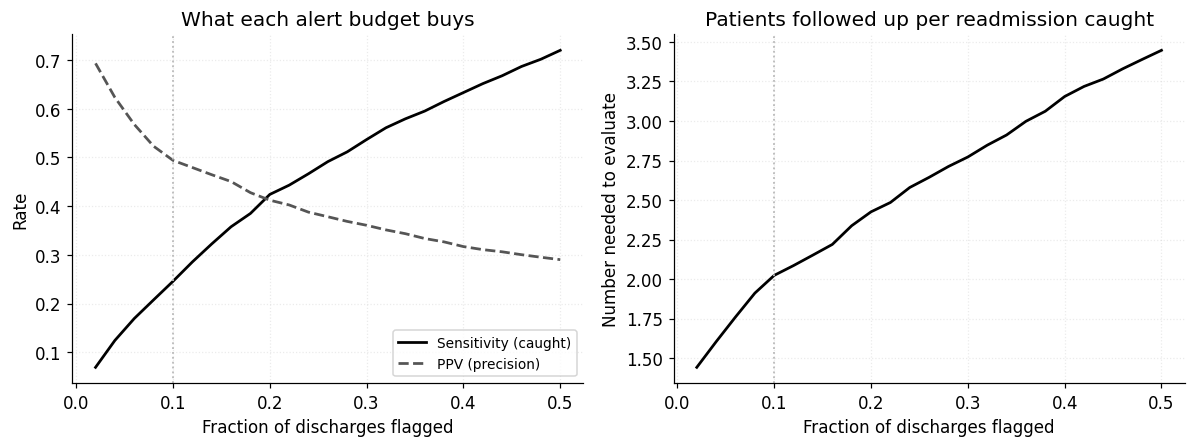

At a 10% alert rate on 14,326 test discharges:
  flag 1,437 patients (risk >= 0.397)
  catch 24.6% of all readmissions
  49.4% of flagged patients are readmitted (vs 20.2% at random)
  lift = 2.45x, NNE = 2.0 patients per readmission caught

Confusion matrix at that threshold:


,predicted: no alert,predicted: alert
actual: no readmit,10708,727
actual: readmit,2181,710


In [33]:
# ----------------------------------------------------------------------------------
# 9.4 Operating-point sweep for the best (recalibrated) model
# ----------------------------------------------------------------------------------
best_probs = prob_cal
rates = np.linspace(0.02, 0.50, 25)
sweep = pd.DataFrame([evaluate(y_test, best_probs, alert_rate=r) for r in rates])
sweep["target_alert_rate"] = rates

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.plot(sweep["target_alert_rate"], sweep["sensitivity"], label="Sensitivity (caught)",
        linewidth=1.8, **style(0))
ax.plot(sweep["target_alert_rate"], sweep["ppv"], label="PPV (precision)",
        linewidth=1.8, **style(1))
ax.axvline(ALERT_RATE, color="#bbbbbb", linestyle=":", linewidth=1.2)
ax.set_xlabel("Fraction of discharges flagged")
ax.set_ylabel("Rate")
ax.set_title("What each alert budget buys")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(sweep["target_alert_rate"], sweep["nne"], linewidth=1.8, **style(0))
ax.axvline(ALERT_RATE, color="#bbbbbb", linestyle=":", linewidth=1.2)
ax.set_xlabel("Fraction of discharges flagged")
ax.set_ylabel("Number needed to evaluate")
ax.set_title("Patients followed up per readmission caught")
fig.tight_layout()
save_fig(fig, "fig07_operating_point")
plt.show()

m = evaluate(y_test, best_probs, alert_rate=ALERT_RATE)
n_flagged = int(round(m["alert_rate"] * len(y_test)))
print(f"At a {ALERT_RATE:.0%} alert rate on {len(y_test):,} test discharges:")
print(f"  flag {n_flagged:,} patients (risk >= {m['threshold']:.3f})")
print(f"  catch {m['sensitivity']:.1%} of all readmissions")
print(f"  {m['ppv']:.1%} of flagged patients are readmitted (vs {m['prevalence']:.1%} at random)")
print(f"  lift = {m['lift']:.2f}x, NNE = {m['nne']:.1f} patients per readmission caught")

cm = confusion_matrix(y_test, (best_probs >= m["threshold"]).astype(int))
print("\nConfusion matrix at that threshold:")
display(pd.DataFrame(cm, index=["actual: no readmit", "actual: readmit"],
                     columns=["predicted: no alert", "predicted: alert"]))

---
## 10. Interpretability — what did the model learn?

Three complementary views, from cheapest to most expensive:

1. **Logistic regression coefficients** → odds ratios. Global, exact for that model, and the
   only one a clinician can check against their own experience line by line.
2. **Permutation importance** → shuffle one column and see how much test AUROC falls.
   Model-agnostic, measured on held-out data, and it reflects what the model *actually uses*.
3. **Partial dependence** → the average predicted risk as one feature varies. Shows the
   *shape* of a relationship, not just its strength.

All three describe **association**, not causation. "Number of prior admissions is important"
does not mean preventing admissions would lower risk; it means prior admissions are a marker
for whatever is actually going on.

Because numeric features were standardised, each coefficient is the change in log-odds per ONE STANDARD DEVIATION of that feature (per category for one-hot columns).

Top 15 by magnitude:


,feature,coef,odds_ratio
88,discharge_location_PSYCH FACILITY,1.967,7.148
87,discharge_location_OTHER FACILITY,-0.850,0.427
81,discharge_location_ACUTE HOSPITAL,-0.753,0.471
121,last_careunit_Surgery/Vascular/Intermediate,-0.511,0.600
74,admission_location_INTERNAL TRANSFER TO OR FRO...,0.477,1.611
109,first_careunit_Surgery/Vascular/Intermediate,-0.437,0.646
65,admission_type_EU OBSERVATION,-0.348,0.706
85,discharge_location_HOME,-0.347,0.707
113,last_careunit_Cardiac Vascular Intensive Care ...,-0.322,0.725
82,discharge_location_AGAINST ADVICE,0.300,1.349


  saved -> readmission_project/figures/fig08_logreg_coefficients.png


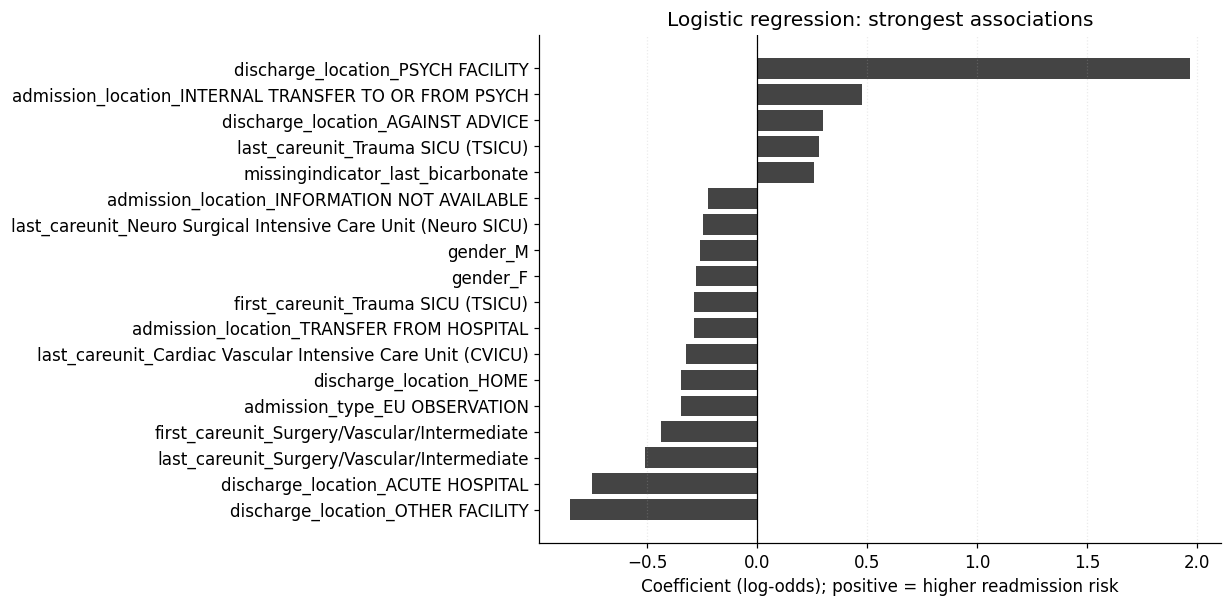

In [34]:
# ----------------------------------------------------------------------------------
# 10.1 Logistic regression odds ratios
# ----------------------------------------------------------------------------------
lr = fitted["Logistic regression"]
feat_names = lr.named_steps["pre"].get_feature_names_out()
coefs = lr.named_steps["clf"].coef_[0]

or_table = (
    pd.DataFrame({"feature": feat_names, "coef": coefs})
    .assign(odds_ratio=lambda d: np.exp(d["coef"]),
            abs_coef=lambda d: d["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)
print("Because numeric features were standardised, each coefficient is the change in "
      "log-odds per ONE STANDARD DEVIATION of that feature (per category for one-hot columns).\n")
print("Top 15 by magnitude:")
display(or_table.head(15)[["feature", "coef", "odds_ratio"]].round(3))

top = or_table.head(18).sort_values("coef")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top["feature"], top["coef"], color=BAR_COLOR)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (log-odds); positive = higher readmission risk")
ax.set_title("Logistic regression: strongest associations")
ax.grid(axis="y", visible=False)
save_fig(fig, "fig08_logreg_coefficients")
plt.show()

permutation importance computed in 32s on 8,000 rows


,feature,drop_in_auroc,sd
47,discharge_location,0.0183,0.0019
1,los_days,0.0105,0.0014
9,n_prior_admits_365d,0.0064,0.0012
39,last_bun,0.0056,0.0005
11,n_prior_admits_total,0.0051,0.0012
42,last_wbc,0.0039,0.0010
40,last_hemoglobin,0.0029,0.0012
10,n_prior_unplanned_365d,0.0029,0.0010
41,last_platelets,0.0024,0.0010
29,metastatic_cancer,0.0020,0.0010


  saved -> readmission_project/figures/fig09_permutation_importance.png


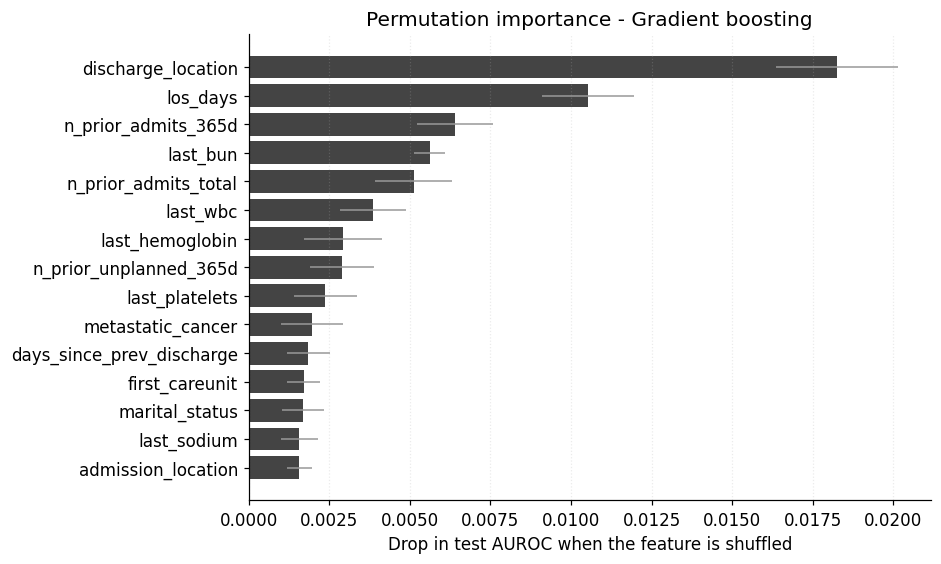

In [35]:
# ----------------------------------------------------------------------------------
# 10.2 Permutation importance for the best model
# ----------------------------------------------------------------------------------
# Because we pass the whole Pipeline, permutation happens on the ORIGINAL columns, so the
# result is one number per feature you actually engineered - not per one-hot dummy. That is
# far more readable.
#
# It is computed on a test subsample for speed; raise `n_sample`/`n_repeats` if you can wait.
from sklearn.inspection import permutation_importance

n_sample = min(8000, len(X_test))
sub = X_test.sample(n_sample, random_state=RANDOM_SEED)
sub_y = y_test.loc[sub.index]

t0 = time.time()
perm = permutation_importance(
    fitted[BEST_MODEL], sub, sub_y,
    scoring="roc_auc", n_repeats=5, random_state=RANDOM_SEED, n_jobs=-1,
)
print(f"permutation importance computed in {time.time() - t0:.0f}s on {n_sample:,} rows")

imp = (pd.DataFrame({"feature": sub.columns,
                     "drop_in_auroc": perm.importances_mean,
                     "sd": perm.importances_std})
       .sort_values("drop_in_auroc", ascending=False))
display(imp.head(15).round(4))

topk = imp.head(15).sort_values("drop_in_auroc")
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(topk["feature"], topk["drop_in_auroc"], xerr=topk["sd"],
        color=BAR_COLOR, error_kw={"ecolor": "#999999", "lw": 1})
ax.set_xlabel("Drop in test AUROC when the feature is shuffled")
ax.set_title(f"Permutation importance - {BEST_MODEL}")
ax.grid(axis="y", visible=False)
save_fig(fig, "fig09_permutation_importance")
plt.show()

  saved -> readmission_project/figures/fig10_partial_dependence.png


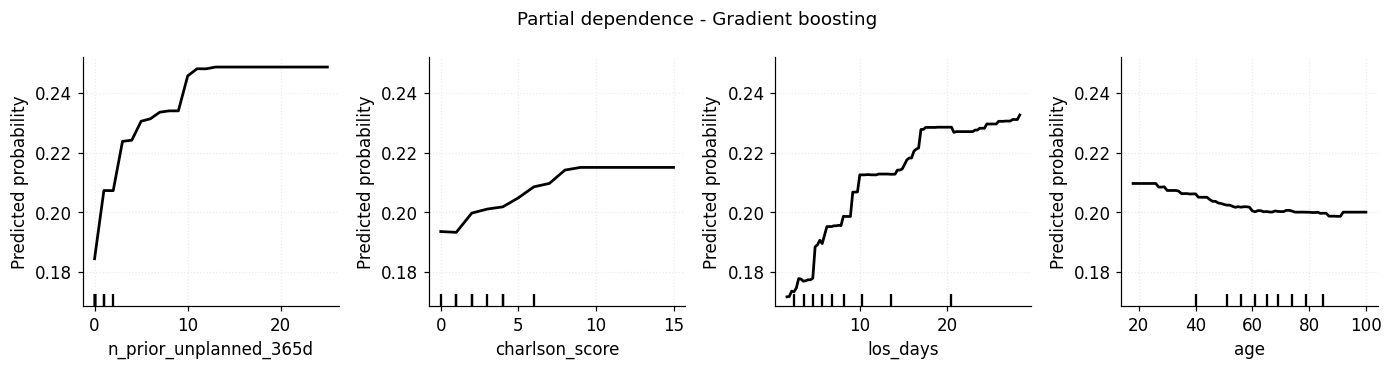

Read these as: 'holding everything else at its observed distribution, how does average predicted risk change as this feature moves?' Flat = the model ignores it. Watch for non-monotone wiggles at the extremes - those are usually sparse data, not biology.


In [36]:
# ----------------------------------------------------------------------------------
# 10.3 Partial dependence: the shape of the relationship
# ----------------------------------------------------------------------------------
from sklearn.inspection import PartialDependenceDisplay

pdp_features = [f for f in ["n_prior_unplanned_365d", "charlson_score", "los_days", "age"]
                if f in X_train.columns]
pdp_sample = X_train.sample(min(4000, len(X_train)), random_state=RANDOM_SEED)

fig, axes = plt.subplots(1, len(pdp_features), figsize=(3.2 * len(pdp_features), 3.4))
PartialDependenceDisplay.from_estimator(
    fitted[BEST_MODEL], pdp_sample, features=pdp_features,
    ax=axes, line_kw={"color": "black", "linewidth": 1.8},
)
for ax in np.atleast_1d(axes):
    ax.set_ylabel("Predicted probability")
fig.suptitle(f"Partial dependence - {BEST_MODEL}", fontsize=12)
fig.tight_layout()
save_fig(fig, "fig10_partial_dependence")
plt.show()

print("Read these as: 'holding everything else at its observed distribution, how does average "
      "predicted risk change as this feature moves?' Flat = the model ignores it. Watch for "
      "non-monotone wiggles at the extremes - those are usually sparse data, not biology.")

In [37]:
# ----------------------------------------------------------------------------------
# 10.4 Optional: SHAP values for per-patient explanations
# ----------------------------------------------------------------------------------
# SHAP attributes a single prediction to individual features, which is what you would show
# at the bedside ("this patient is flagged mainly because of X and Y"). Install with
# `pip install shap`. Skipped silently if unavailable.
try:
    import shap

    pre = fitted[BEST_MODEL].named_steps["pre"]
    clf = fitted[BEST_MODEL].named_steps["clf"]
    Xs = pre.transform(X_test.sample(min(2000, len(X_test)), random_state=RANDOM_SEED))
    names = pre.get_feature_names_out()

    explainer = shap.Explainer(clf, Xs, feature_names=names)
    shap_values = explainer(Xs[:500])
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title(f"SHAP summary - {BEST_MODEL}")
    save_fig(plt.gcf(), "fig11_shap_summary")
    plt.show()
except ImportError:
    print("shap not installed - skipping (pip install shap to enable).")
except Exception as exc:
    print(f"SHAP step skipped: {type(exc).__name__}: {exc}")

shap not installed - skipping (pip install shap to enable).


---
## 11. Subgroup audit

A single AUROC hides the possibility that a model works well for one group of patients and
poorly for another. A model deployed in a hospital is applied to everyone, so it needs to be
checked on everyone.

We report, for each subgroup: outcome prevalence, AUROC, and — at the **single shared
threshold** the model would actually be deployed with — the alert rate and sensitivity.

Three things to keep in mind when reading the table:

1. **Different prevalence is not by itself unfairness.** If one group genuinely has more
   readmissions, a well-calibrated model will flag more of them. That is the model working.
2. **Different *sensitivity* at a shared threshold is worth attention.** If the model catches
   60% of readmissions in one group and 35% in another, the second group systematically
   receives less of the benefit.
3. **Small groups have wide uncertainty.** An AUROC computed on 80 patients with 6 events is
   noise. We print group sizes next to every metric for exactly this reason, and leave AUROC
   blank for groups too small to estimate it. Groups with fewer than 11 admissions are never
   shown on their own: they are pooled into "(other)" (or withheld if even that is tiny),
   because a cell that small is pure noise and can reveal an individual patient's outcome.

**On race specifically.** In MIMIC, recorded race is a crude, administratively-collected
variable that acts as a proxy for structural factors (insurance, neighbourhood, access to
follow-up care, differential treatment) rather than a biological cause. Including it as a
model input can improve accuracy while encoding those inequities into future decisions; that
is the argument for `USE_RACE_AS_FEATURE = False`. The counter-argument — that a model blind
to race cannot be checked for or corrected against disparities — is also serious, which is
exactly why we *audit* on race even though we do not *train* on it.

In [38]:
# ----------------------------------------------------------------------------------
# 11.1 Subgroup metrics at a single shared operating threshold
# ----------------------------------------------------------------------------------
shared_threshold = threshold_for_alert_rate(best_probs, ALERT_RATE)
MIN_GROUP_N, MIN_GROUP_EVENTS = 200, 20   # below either one, AUROC is too noisy to report
MIN_CELL = 11                             # never show a group with fewer admissions than this
                                          # (the widely used "no cells of 1-10" disclosure rule)


def subgroup_report(series, label, top=None):
    """Metrics per level of `series`, evaluated at the shared deployment threshold.

    Levels outside the `top` most common, and any level with fewer than MIN_CELL admissions,
    are pooled into "(other)". If that pooled group is itself smaller than MIN_CELL, it is
    left out of the table: a "group" of one or two patients would reveal their outcomes.
    """
    s = series.fillna("(missing)").astype(str)   # missing is a level of its own, not "(other)"
    if top is not None:
        keep = s.value_counts().head(top).index
        s = s.where(s.isin(keep), other="(other)")
    counts = s.value_counts()
    s = s.where(~s.isin(counts[counts < MIN_CELL].index), other="(other)")

    # `test` was reset_index'd, so row position == index label; we can mask positionally,
    # which keeps `best_probs` (a plain numpy array) correctly aligned.
    y_arr = np.asarray(y_test)
    rows = []
    for level in sorted(s.unique().tolist()):
        mask = (s == level).to_numpy()
        pos = y_arr[mask]
        pr = best_probs[mask]
        flagged = (pr >= shared_threshold).astype(int)
        n, ev = len(pos), int(pos.sum())
        if n < MIN_CELL:           # only a pooled "(other)" can still be this small
            continue
        too_small = n < MIN_GROUP_N or ev < MIN_GROUP_EVENTS
        rows.append({
            label: str(level),
            "n": n,
            "events": ev,
            "prevalence": pos.mean(),
            "auroc": np.nan if too_small else roc_auc_score(pos, pr),
            "alert_rate": flagged.mean(),
            "sensitivity": np.nan if ev == 0 else flagged[pos == 1].mean(),
            "ppv": np.nan if flagged.sum() == 0 else pos[flagged == 1].mean(),
        })
    return pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)


test_race = test["race"]
age_band = pd.cut(test["age"], [17, 40, 55, 70, 85, 120],
                  labels=["18-39", "40-54", "55-69", "70-84", "85+"])

print(f"n = admissions in the test set. AUROC is left blank for groups with < {MIN_GROUP_N} "
      f"admissions or < {MIN_GROUP_EVENTS} events;\ngroups with < {MIN_CELL} admissions are pooled "
      f"into '(other)', or not shown at all if the pool is still that small.")
for series, label, top in [
    (test["gender"], "sex", None),
    (age_band.astype(str), "age band", None),
    (test["insurance"], "insurance", 5),
    (test_race, "race (audit only)", 6),
]:
    print(f"\n=== by {label} ===")
    display(subgroup_report(series, label, top=top).round(3))

n = admissions in the test set. AUROC is left blank for groups with < 200 admissions or < 20 events;
groups with < 11 admissions are pooled into '(other)', or not shown at all if the pool is still that small.

=== by sex ===


,sex,n,events,prevalence,auroc,alert_rate,sensitivity,ppv
0,M,8068,1596,0.198,0.707,0.099,0.241,0.481
1,F,6258,1295,0.207,0.698,0.102,0.252,0.511



=== by age band ===


,age band,n,events,prevalence,auroc,alert_rate,sensitivity,ppv
0,55-69,4876,957,0.196,0.701,0.101,0.230,0.448
1,70-84,4170,831,0.199,0.668,0.076,0.172,0.454
2,40-54,2518,524,0.208,0.721,0.119,0.294,0.513
3,18-39,1613,351,0.218,0.796,0.177,0.481,0.591
4,85+,1149,228,0.198,0.629,0.039,0.105,0.533



=== by insurance ===


,insurance,n,events,prevalence,auroc,alert_rate,sensitivity,ppv
0,Medicare,7463,1587,0.213,0.685,0.098,0.229,0.495
1,Private,4046,700,0.173,0.715,0.076,0.221,0.505
2,Medicaid,2241,516,0.230,0.708,0.159,0.328,0.473
3,Other,352,61,0.173,0.711,0.094,0.279,0.515
4,(missing),223,27,0.121,0.791,0.031,0.222,0.857



=== by race (audit only) ===


,race (audit only),n,events,prevalence,auroc,alert_rate,sensitivity,ppv
0,WHITE,9084,1912,0.210,0.675,0.091,0.201,0.463
1,(other),1676,379,0.226,0.709,0.122,0.282,0.525
2,BLACK/AFRICAN AMERICAN,1310,354,0.270,0.754,0.211,0.452,0.578
3,UNKNOWN,1113,62,0.056,0.780,0.043,0.339,0.438
4,OTHER,527,94,0.178,0.696,0.076,0.170,0.400
5,WHITE - OTHER EUROPEAN,369,77,0.209,0.712,0.098,0.273,0.583
6,UNABLE TO OBTAIN,247,13,0.053,NaN,0.012,0.077,0.333


  saved -> readmission_project/figures/fig12_subgroup_audit.png


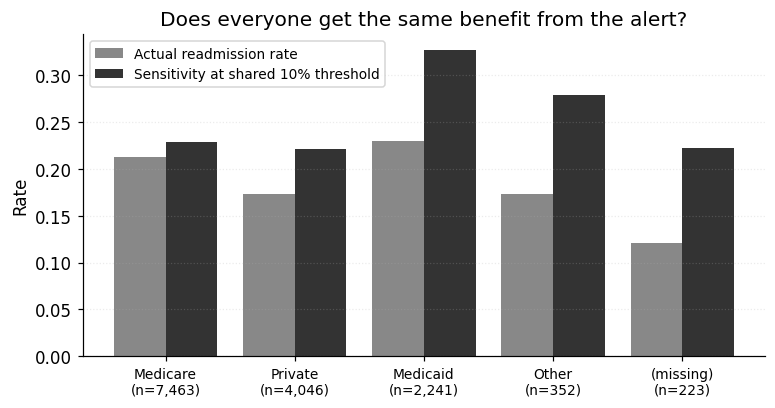

In [39]:
# ----------------------------------------------------------------------------------
# 11.2 Visualise the gap that matters: sensitivity at a shared threshold
# ----------------------------------------------------------------------------------
rep = subgroup_report(test["insurance"], "insurance", top=5)
rep = rep[rep["n"] >= MIN_GROUP_N]

fig, ax = plt.subplots(figsize=(8, 3.8))
x = np.arange(len(rep))
ax.bar(x - 0.2, rep["prevalence"], width=0.4, color="#888888", label="Actual readmission rate")
ax.bar(x + 0.2, rep["sensitivity"], width=0.4, color="#333333",
       label=f"Sensitivity at shared {ALERT_RATE:.0%} threshold")
ax.set_xticks(x)
ax.set_xticklabels([f"{v}\n(n={n:,})" for v, n in zip(rep["insurance"], rep["n"])], fontsize=9)
ax.set_ylabel("Rate")
ax.set_title("Does everyone get the same benefit from the alert?")
ax.legend(fontsize=9)
ax.grid(axis="x", visible=False)
save_fig(fig, "fig12_subgroup_audit")
plt.show()

---
## 12. Temporal validation — will it still work next year?

A random split assumes the future looks like the past. It never quite does: coding practice
changes (ICD-9 → ICD-10 is visible right inside this dataset), care pathways change,
populations change, and in 2020 everything changed at once.

`anchor_year_group` places each *patient* in a real 3-year calendar window (the one containing
their anchor year). We train on patients from the earlier windows and test on patients from the
latest one — the closest thing to a prospective evaluation that retrospective data allows.
Because the grouping is per patient, this split is automatically patient-disjoint. It is also
approximate: one patient's admissions can span several real years.

A temporal shift can hurt a model in two different ways, so check both:

1. **Discrimination can fall.** If the relationships the model learned have drifted, AUROC drops.
   A drop of a few hundredths is common.
2. **The base rate can move.** If readmissions become rarer (or commoner), PPV and
   number-needed-to-evaluate change and the probabilities become miscalibrated — even when AUROC
   holds steady. Comparing *mean predicted risk* with the *observed rate* shows this at a glance.

Whichever you find, the temporal numbers are the honest estimate of how the model would do after
deployment, and they are the numbers to quote.

In [40]:
# ----------------------------------------------------------------------------------
# 12.1 Train on earlier years, test on the most recent year group
# ----------------------------------------------------------------------------------
year_groups = sorted(data["anchor_year_group"].dropna().unique())
print("Available year groups:")
display(data.groupby("anchor_year_group")[TARGET].agg(["size", "mean"]).round(3))

holdout_group = year_groups[-1] if len(year_groups) >= 2 else None
if holdout_group is not None:
    tr = data[data["anchor_year_group"] != holdout_group]
    te = data[data["anchor_year_group"] == holdout_group]

# Both sides need readmitted AND non-readmitted patients, or AUROC is undefined. This only
# bites on very small extracts (such as the 100-patient MIMIC-IV demo), never on the full data.
if holdout_group is None or tr[TARGET].nunique() < 2 or te[TARGET].nunique() < 2:
    print("Not enough year groups (or outcomes) for a temporal split - skipped.")
else:
    print(f"\nTrain on {year_groups[:-1]}  ->  {len(tr):,} admissions")
    print(f"Test  on ['{holdout_group}']  ->  {len(te):,} admissions")

    # clone() is essential: `models[BEST_MODEL]` and `fitted[BEST_MODEL]` are the SAME
    # object, so refitting it here would silently overwrite the model we evaluated above.
    from sklearn.base import clone
    temporal_pipe = clone(models[BEST_MODEL])
    temporal_pipe.fit(tr[model_cols], tr[TARGET])
    temporal_probs = temporal_pipe.predict_proba(te[model_cols])[:, 1]
    temporal_metrics = evaluate(te[TARGET], temporal_probs)

    # "Calibration-in-the-large": the average predicted risk vs the rate actually observed.
    random_col = results.loc[BEST_MODEL].copy()
    random_col["mean_predicted"] = float(np.mean(test_probs[BEST_MODEL]))
    temporal_col = pd.Series(temporal_metrics)
    temporal_col["mean_predicted"] = float(np.mean(temporal_probs))

    side_by_side = pd.DataFrame({
        "random patient-wise split": random_col,
        f"temporal split (test = {holdout_group})": temporal_col,
    }).loc[["auroc", "auprc", "brier", "prevalence", "mean_predicted", "sensitivity", "ppv", "nne"]]
    display(side_by_side.round(3))

    # Interpret what actually happened, in both of the ways described above.
    change = temporal_metrics["auroc"] - results.loc[BEST_MODEL, "auroc"]
    print(f"\n1) AUROC change under temporal validation: {change:+.3f}")
    if change < -0.06:
        print("   A large drop: the model leans on something that is not stable over time. Check "
              "whether coding practice or care-unit naming changed between year groups.")
    elif change < -0.01:
        print("   A modest drop, typical of real temporal shift. Quote this number, not the "
              "random-split one.")
    elif change > 0.02:
        print("   AUROC went UP. That is rarely the model getting better: the newest patients may "
              "simply be easier to rank (a different case mix), and a small test set moves AUROC "
              "by a few hundredths by chance.")
    else:
        print("   Discrimination held up: the model ranks the newest patients about as well.")

    obs, pred = temporal_metrics["prevalence"], temporal_col["mean_predicted"]
    print(f"2) Observed readmission rate {obs:.1%} vs mean predicted risk {pred:.1%} "
          f"(random split: {random_col['prevalence']:.1%} observed)")
    if pred > 1.2 * obs:
        print("   The base rate fell and the model now OVER-predicts: PPV and NNE get worse, and "
              "the probabilities would need recalibrating on recent data before deployment.")
    elif pred < obs / 1.2:
        print("   The base rate rose and the model now UNDER-predicts: it would miss risk unless "
              "recalibrated on recent data.")
    else:
        print("   Predicted and observed rates agree: calibration survived the shift.")

Available year groups:


,size,mean
anchor_year_group,,
2008 - 2010,23066,0.255
2011 - 2013,14950,0.207
2014 - 2016,13734,0.177
2017 - 2019,12185,0.161
2020 - 2022,7808,0.134



Train on ['2008 - 2010', '2011 - 2013', '2014 - 2016', '2017 - 2019']  ->  63,935 admissions
Test  on ['2020 - 2022']  ->  7,808 admissions


,random patient-wise split,temporal split (test = 2020 - 2022)
auroc,0.704,0.706
auprc,0.408,0.327
brier,0.144,0.106
prevalence,0.202,0.134
mean_predicted,0.201,0.166
sensitivity,0.245,0.274
ppv,0.495,0.367
nne,2.021,2.721



1) AUROC change under temporal validation: +0.001
   Discrimination held up: the model ranks the newest patients about as well.
2) Observed readmission rate 13.4% vs mean predicted risk 16.6% (random split: 20.2% observed)
   The base rate fell and the model now OVER-predicts: PPV and NNE get worse, and the probabilities would need recalibrating on recent data before deployment.


---
## 13. Save everything

A tutorial that cannot be re-run is a blog post. Save the fitted pipeline, the metrics, and
enough metadata that a reader (including you, in six months) can tell exactly what produced
a given number — plus one summary file holding every number the slides need (13.3).

In [41]:
# ----------------------------------------------------------------------------------
# 13.1 Persist model, metrics and run metadata
# ----------------------------------------------------------------------------------
import joblib

joblib.dump(calibrated, MODEL_DIR / "readmission_model_calibrated.joblib")
joblib.dump(fitted[BEST_MODEL], MODEL_DIR / "readmission_model_raw.joblib")

run_record = {
    "created": pd.Timestamp.now().isoformat(timespec="seconds"),
    "data_source": "MIMIC-IV v3.1",
    "outcome": f"unplanned readmission within {READMIT_WINDOW_DAYS} days of discharge",
    "cohort": {
        "n_admissions": int(len(data)),
        "n_patients": int(data[GROUP].nunique()),
        "outcome_rate": float(data[TARGET].mean()),
    },
    "split": {"type": "GroupShuffleSplit by subject_id", "test_size": TEST_SIZE,
              "random_state": RANDOM_SEED},
    "features": {"numeric": NUMERIC_FEATURES, "categorical": CATEGORICAL_FEATURES,
                 "race_used_as_feature": USE_RACE_AS_FEATURE},
    "best_model": BEST_MODEL,
    "test_metrics": {k: (None if pd.isna(v) else float(v))
                     for k, v in results.loc[BEST_MODEL].items()},
    "calibrated_test_metrics": {k: (None if pd.isna(v) else float(v))
                                for k, v in cal_metrics.items()},
    "versions": {"python": sys.version.split()[0], "pandas": pd.__version__,
                 "numpy": np.__version__, "scikit_learn": sklearn.__version__},
}
with open(MODEL_DIR / "run_record.json", "w") as fh:
    json.dump(run_record, fh, indent=2)

results.round(4).to_csv(PROJECT_DIR / "test_metrics.csv")
cv_results.round(4).to_csv(PROJECT_DIR / "cv_metrics.csv", index=False)

print("Saved:")
for p in sorted(PROJECT_DIR.rglob("*")):
    if p.is_file() and "cache" not in p.parts:
        print(f"  {p.relative_to(PROJECT_DIR)}  ({p.stat().st_size / 1024:.0f} KB)")

Saved:
  cohort_flow.csv  (0 KB)
  cv_metrics.csv  (0 KB)
  figures\fig01_cohort_flow.png  (92 KB)
  figures\fig02_time_to_readmission.png  (61 KB)
  figures\fig03_missingness.png  (95 KB)
  figures\fig04_risk_factors.png  (126 KB)
  figures\fig05_roc_pr.png  (187 KB)
  figures\fig06_calibration.png  (171 KB)
  figures\fig07_operating_point.png  (141 KB)
  figures\fig08_logreg_coefficients.png  (199 KB)
  figures\fig09_permutation_importance.png  (113 KB)
  figures\fig10_partial_dependence.png  (87 KB)
  figures\fig12_subgroup_audit.png  (58 KB)
  models\readmission_model_calibrated.joblib  (1426 KB)
  models\readmission_model_raw.joblib  (480 KB)
  models\run_record.json  (3 KB)
  test_metrics.csv  (0 KB)


In [42]:
# ----------------------------------------------------------------------------------
# 13.2 Score a new patient (what deployment would actually look like)
# ----------------------------------------------------------------------------------
# The saved pipeline takes a raw DataFrame with the original columns and handles imputation,
# encoding and scaling internally. That is the payoff for using a Pipeline rather than
# transforming the data by hand.
#
# We score a HYPOTHETICAL patient rather than a real row: every numeric input is set to the
# training-set median and every categorical input to its most common value. That shows the
# interface without printing any real person's record or outcome, which keeps this notebook's
# output aggregate-only - safe to share, in line with the Data Use Agreement.
loaded = joblib.load(MODEL_DIR / "readmission_model_calibrated.joblib")


def most_common(s):
    m = s.mode(dropna=True)
    return m.iloc[0] if len(m) else np.nan


typical = {c: X_train[c].median() for c in NUMERIC_FEATURES}
typical.update({c: most_common(X_train[c]) for c in CATEGORICAL_FEATURES})
example = pd.DataFrame([typical])[model_cols]

# A what-if: the same patient, but with three unplanned admissions in the past year.
what_if = example.copy()
what_if["n_prior_unplanned_365d"] = 3
for col in ("n_prior_admits_365d", "n_prior_admits_total"):
    what_if[col] = max(3, float(example[col].iloc[0]))
what_if["is_first_admission"] = 0

for label, row in [("Typical patient", example),
                   ("Same patient, 3 unplanned admissions last year", what_if)]:
    risk = loaded.predict_proba(row)[0, 1]
    decision = "FLAG for transitional-care follow-up" if risk >= shared_threshold else "no alert"
    print(f"{label:<48} risk {risk:6.1%}  ->  {decision}")

print(f"\nTest-set readmission rate:              {y_test.mean():.1%}")
print(f"Alert threshold ({ALERT_RATE:.0%} alert rate):         {shared_threshold:.1%}")
print("\n(A made-up patient proves nothing about the model. It demonstrates the interface, and "
      "shows the prediction responding when the prior-admission history changes.)")

Typical patient                                  risk  10.8%  ->  no alert
Same patient, 3 unplanned admissions last year   risk  23.2%  ->  no alert

Test-set readmission rate:              20.2%
Alert threshold (10% alert rate):         39.7%

(A made-up patient proves nothing about the model. It demonstrates the interface, and shows the prediction responding when the prior-admission history changes.)


In [43]:
# ----------------------------------------------------------------------------------
# 13.3 One file with every number the slide deck needs
# ----------------------------------------------------------------------------------
# Numbers copied onto slides by hand go stale the moment you re-run with a different
# setting. So we collect every headline number straight from the variables above into
# results_summary.md (readable, paste-able) and results_summary.json (machine-readable).
# Everything in these two files is aggregate - counts, rates, metrics - so, unlike anything
# in CACHE_DIR, they are safe to share (e.g. when you build your slides).
from IPython.display import Markdown

FIGURE_CAPTIONS = {
    "fig01_cohort_flow": "Cohort construction flow (the CONSORT-style diagram)",
    "fig02_time_to_readmission": "Days from discharge to unplanned readmission",
    "fig03_missingness": "Missing data by feature",
    "fig04_risk_factors": "Readmission rate by candidate risk factor",
    "fig05_roc_pr": "ROC and precision-recall curves, all models",
    "fig06_calibration": "Calibration, as fitted and after isotonic recalibration",
    "fig07_operating_point": "What each alert budget buys: sensitivity, PPV, NNE",
    "fig08_logreg_coefficients": "Logistic regression: strongest associations",
    "fig09_permutation_importance": "Permutation importance, model carried forward",
    "fig10_partial_dependence": "Partial dependence for four key features",
    "fig11_shap_summary": "SHAP summary (only if shap is installed)",
    "fig12_subgroup_audit": "Subgroup audit: prevalence vs sensitivity by insurance",
}


def md_table(df, index_label=None, digits=3):
    """Render a small DataFrame as a Markdown table (no extra packages needed)."""
    if index_label is not None:
        df = df.rename_axis(index_label).reset_index()

    def fmt(v):
        if isinstance(v, (bool, np.bool_)):
            return str(v)
        if isinstance(v, (int, np.integer)):
            return f"{int(v):,}"
        if isinstance(v, (float, np.floating)):
            if pd.isna(v):
                return ""
            return f"{v:,.{digits}f}".rstrip("0").rstrip(".") if "." in f"{v:,.{digits}f}" else f"{v:,.{digits}f}"
        return str(v)

    lines = ["| " + " | ".join(str(c) for c in df.columns) + " |", "|" + "---|" * df.shape[1]]
    lines += ["| " + " | ".join(fmt(v) for v in row) + " |" for row in df.itertuples(index=False)]
    return "\n".join(lines)


def to_jsonable(o):
    """Convert numpy / pandas scalars (and NaN) into plain JSON-friendly Python values."""
    if isinstance(o, dict):
        return {str(k): to_jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_jsonable(v) for v in o]
    if isinstance(o, (bool, np.bool_)):
        return bool(o)
    if isinstance(o, (int, np.integer)):
        return int(o)
    if isinstance(o, (float, np.floating)):
        return None if pd.isna(o) else round(float(o), 5)
    if o is None or o is pd.NA or o is pd.NaT:
        return None
    return o if isinstance(o, str) else str(o)


m_op = evaluate(y_test, best_probs, alert_rate=ALERT_RATE)
tn, fp, fn, tp = confusion_matrix(y_test, (best_probs >= m_op["threshold"]).astype(int),
                                  labels=[0, 1]).ravel()
subgroups = {
    "sex": subgroup_report(test["gender"], "sex"),
    "age band": subgroup_report(age_band.astype(str), "age band"),
    "insurance": subgroup_report(test["insurance"], "insurance", top=5),
    "race (audit only)": subgroup_report(test["race"], "race (audit only)", top=6),
}
temporal_done = "side_by_side" in globals()
figures = sorted(p.stem for p in FIG_DIR.glob("*.png"))

headline = {
    "Cohort": f"{len(data):,} admissions from {data[GROUP].nunique():,} patients",
    "Outcome rate": f"{data[TARGET].mean():.1%} ({int(data[TARGET].sum()):,} readmissions)",
    "Model carried forward (chosen by CV)": BEST_MODEL,
    "Test AUROC / AUPRC": f"{results.loc[BEST_MODEL, 'auroc']:.3f} / {results.loc[BEST_MODEL, 'auprc']:.3f}",
    "Brier: raw -> recalibrated": f"{results.loc[BEST_MODEL, 'brier']:.4f} -> {cal_metrics['brier']:.4f}",
    f"At a {ALERT_RATE:.0%} alert rate": (
        f"flags {tp + fp:,} of {len(y_test):,}; catches {m_op['sensitivity']:.1%} of readmissions; "
        f"PPV {m_op['ppv']:.1%}; NNE {m_op['nne']:.1f}; lift {m_op['lift']:.2f}x"),
    "Temporal-split AUROC": (f"{side_by_side.loc['auroc'].iloc[1]:.3f} (test = {holdout_group}) vs "
                             f"{side_by_side.loc['auroc'].iloc[0]:.3f} random split"
                             if temporal_done else "not run"),
}
headline_md = md_table(pd.DataFrame({"value": headline}), index_label="quantity")

md = [
    "# Results summary: 30-day unplanned readmission after an ICU stay (MIMIC-IV v3.1)", "",
    f"_Generated {pd.Timestamp.now():%Y-%m-%d %H:%M} by the tutorial notebook. "
    "Aggregate results only: no patient-level data._", "",
    "## Headline numbers", "", headline_md, "",
    "## Cohort flow", "", md_table(flow_df), "",
    "## Cross-validation (training set, patient-grouped folds)", "",
    md_table(cv_results.drop(columns="fit_seconds")), "",
    "## Held-out test set", "",
    md_table(results[["auroc", "auprc", "brier", "sensitivity", "ppv", "nne", "lift"]], index_label="model"), "",
    f"## Operating point: flag the top {ALERT_RATE:.0%} (model carried forward, recalibrated)", "",
    md_table(pd.DataFrame({"predicted: no alert": [tn, fn], "predicted: alert": [fp, tp]},
                          index=["actual: no readmit", "actual: readmit"]), index_label=""), "",
    "## What drives the predictions", "",
    "Permutation importance (drop in test AUROC when the feature is shuffled):", "",
    md_table(imp.head(10), digits=4), "",
    "Logistic regression, largest coefficients (per SD for numeric features):", "",
    md_table(or_table.head(10)[["feature", "coef", "odds_ratio"]]), "",
    "## Subgroup audit (one shared threshold)", "",
    f"n = test-set admissions. A blank AUROC means the group is too small to estimate it "
    f"(< {MIN_GROUP_N} admissions or < {MIN_GROUP_EVENTS} events); groups with < {MIN_CELL} "
    f"admissions are pooled into '(other)' or withheld.", "",
]
for name, table in subgroups.items():
    md += [f"**By {name}**", "", md_table(table), ""]
md += ["## Temporal validation", "",
       md_table(side_by_side, index_label="metric") if temporal_done else "Not run.", "",
       "## Figures (in readmission_project/figures/)", ""]
md += [f"- `{f}.png` - {FIGURE_CAPTIONS.get(f, '')}" for f in figures]

summary = {
    "setup": {
        "data_source": "MIMIC-IV v3.1",
        "outcome": f"unplanned readmission within {READMIT_WINDOW_DAYS} days of discharge",
        "population": f"adults (>= {MIN_AGE}) discharged alive after a hospitalisation with an ICU stay",
        "alert_rate": ALERT_RATE, "random_seed": RANDOM_SEED, "test_size": TEST_SIZE,
        "cv_folds": N_CV_FOLDS, "use_labs": USE_LABS, "use_prescriptions": USE_PRESCRIPTIONS,
        "race_used_as_feature": USE_RACE_AS_FEATURE,
        "n_features": {"numeric": len(NUMERIC_FEATURES), "categorical": len(CATEGORICAL_FEATURES)},
    },
    "headline": headline,
    "cohort_flow": flow_df.to_dict(orient="records"),
    "split": {"train_admissions": len(train), "train_patients": train[GROUP].nunique(),
              "test_admissions": len(test), "test_patients": test[GROUP].nunique(),
              "naive_rowwise_split_shared_patients": len(naive_overlap)},
    "cross_validation": cv_results.to_dict(orient="records"),
    "test_metrics": results.rename_axis("model").reset_index().to_dict(orient="records"),
    "model_carried_forward": BEST_MODEL,
    "calibration": {"brier_raw": results.loc[BEST_MODEL, "brier"], "brier_recalibrated": cal_metrics["brier"]},
    "operating_point": {**m_op, "n_test": len(y_test), "n_flagged": tp + fp,
                        "confusion": {"tn": tn, "fp": fp, "fn": fn, "tp": tp}},
    "top_permutation_importance": imp.head(10).to_dict(orient="records"),
    "top_logreg_coefficients": or_table.head(10)[["feature", "coef", "odds_ratio"]].to_dict(orient="records"),
    "subgroups": {k: v.to_dict(orient="records") for k, v in subgroups.items()},
    "temporal": side_by_side.to_dict() if temporal_done else None,
    "figures": figures,
}

(PROJECT_DIR / "results_summary.md").write_text("\n".join(md) + "\n", encoding="utf-8")
with open(PROJECT_DIR / "results_summary.json", "w", encoding="utf-8") as fh:
    json.dump(to_jsonable(summary), fh, indent=2)
print(f"  saved -> {rel(PROJECT_DIR / 'results_summary.md')}")
print(f"  saved -> {rel(PROJECT_DIR / 'results_summary.json')}\n")
display(Markdown("### Headline numbers for your slides\n\n" + headline_md))

  saved -> readmission_project/results_summary.md
  saved -> readmission_project/results_summary.json



### Headline numbers for your slides

| quantity | value |
|---|---|
| Cohort | 71,743 admissions from 55,492 patients |
| Outcome rate | 20.1% (14,433 readmissions) |
| Model carried forward (chosen by CV) | Gradient boosting |
| Test AUROC / AUPRC | 0.704 / 0.408 |
| Brier: raw -> recalibrated | 0.1445 -> 0.1446 |
| At a 10% alert rate | flags 1,437 of 14,326; catches 24.6% of readmissions; PPV 49.4%; NNE 2.0; lift 2.45x |
| Temporal-split AUROC | 0.706 (test = 2020 - 2022) vs 0.704 random split |

---
## 14. What this model is, and what it is not

### Summary of results

Cell 13.3 collected the headline numbers from this run and saved them, with every supporting
table, to `readmission_project/results_summary.md` (and `.json`). Take the numbers for your slides
from that file rather than retyping them, and regenerate it whenever you change a setting. The six
a results slide needs: cohort size and outcome rate; the model carried forward; its test AUROC and
AUPRC; what the 10% alert rate buys (share of readmissions caught, NNE); and the temporal-split
AUROC, shown next to the random-split one.

### Limitations you must state out loud

1. **Single centre, historical.** One Boston academic medical centre, 2008–2022. Nothing here
   licenses a claim about any other hospital.
2. **Readmissions elsewhere are invisible.** A patient readmitted to a different hospital is
   labelled a non-event. Our measured rate is a floor.
3. **Death is handled by exclusion.** The model estimates risk *for patients who survive the
   window*, which is not the same as risk for everyone at discharge.
4. **Billing codes are not clinical truth.** ICD codes are generated for reimbursement. The
   Charlson score built from them measures *coded* comorbidity, which correlates with — but
   is not — disease burden.
5. **The most important predictors are absent.** Housing stability, transport, caregiver
   support, health literacy, whether a follow-up appointment was actually booked. Their
   absence is a large part of why AUROC plateaus around 0.7.
6. **This is a triage aid.** It ranks patients for a scarce resource. It must never be used
   to delay or deny discharge, and it has not been prospectively validated.
7. **Performance is not uniform across subgroups** (Section 11). Report those numbers
   alongside the headline ones, never instead of them.

### Where to take it next

* **Competing-risks survival model** (Fine–Gray) instead of excluding deaths.
* **Add the first-24h ICU physiology** from `chartevents` using the same streaming pattern as
  Section 5.3 — vitals, ventilation, vasopressors.
* **Add clinical text.** `MIMIC-IV-Note` is a separate PhysioNet module containing discharge
  summaries; a fine-tuned clinical transformer or an LLM-derived embedding on top of these
  structured features is a genuine multimodal-fusion project.
* **Compare against a published score** such as LACE or HOSPITAL and report the difference.
* **Report to a standard.** Write the whole thing up against
  [TRIPOD+AI](https://www.bmj.com/content/385/bmj-2023-078378), the reporting guideline for
  clinical prediction models.

---
## 15. Exercises

Work through these to prove to yourself that you own the pipeline. Each one is a small,
self-contained change with a predictable direction of effect — if the result surprises you,
that is where the learning is.

1. **Change the horizon.** Set `READMIT_WINDOW_DAYS = 7`, then `90`. Which is easier to
   predict, and why do you think so?
2. **Break it on purpose.** Add `days_to_next` to `NUMERIC_FEATURES` and re-run Section 9.
   Watch AUROC jump towards 1.0. This is what leakage looks like from the inside — learn to
   recognise the feeling of a suspiciously good result.
3. **Break the split.** Replace `GroupShuffleSplit` with a plain `train_test_split` and
   measure how much the AUROC inflates. Report the difference.
4. **Relax the label.** Count *any* unplanned admission within 30 days, not just the next
   one. How much does the outcome rate move?
5. **Make the elective decision explicit.** Set `UNPLANNED_TYPES = observed_types` (count
   everything). Does performance go up or down, and is the resulting model more or less
   useful?
6. **Tune something.** Run a small `RandomizedSearchCV` over the gradient-boosting
   hyperparameters using `StratifiedGroupKFold`. How much AUROC does tuning actually buy you
   compared to the jump from logistic regression to boosting?
7. **Add a table.** Bring in `services.csv.gz` (the clinical service that cared for the
   patient) or `transfers.csv.gz` (count of ward moves) and see whether either adds signal.
8. **Subgroup threshold.** Section 11 uses one shared threshold. What happens to overall
   sensitivity and to the subgroup gaps if you set a per-group threshold instead? Is that an
   improvement, and who decides?

---
## Appendix A — Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| `FileNotFoundError: MIMIC_DIR does not exist` or `Could not find table ...` | `MIMIC_DIR` is not the folder containing `hosp/` and `icu/` | Fix it in your `MIMIC_DIR` variable, `mimic_path.txt`, or the placeholder in 1.2 (usually one level up or down); the printout in 1.3 shows what it found |
| Kernel dies while reading `labevents` | Chunk too large for available RAM | Lower `CHUNKSIZE` to 500_000 |
| `MemoryError` on `pd.concat` | Too many kept rows | Aggregate inside the chunk loop instead of collecting all of them |
| Outcome rate is 0.00% | `UNPLANNED_TYPES` does not match the spellings in your release | Re-read the value counts in Section 3.5 and edit the set |
| AUROC ≈ 1.00 | Leakage | Check `FORBIDDEN`; print `model_cols` and read every name |
| `ValueError: Found unknown categories` | A category in test never appeared in train | Already handled by `handle_unknown="ignore"`; if you replaced the encoder, put it back |
| Columns named `age_x`, `age_y` | You re-ran a merge cell twice | Restart the kernel and run from the top — merges are not idempotent |
| `to_parquet` raises `ImportError` | `pyarrow` not installed | `pip install pyarrow`, or ignore — the code falls back to CSV |

## Appendix B — Reproducibility checklist

- [ ] Kernel → Restart & Run All completes with no errors
- [ ] `RANDOM_SEED` is used by every split, model and sampler
- [ ] Cohort flow table is saved (`cohort_flow.csv`)
- [ ] Package versions recorded (`run_record.json`)
- [ ] Figures regenerate into `figures/` with stable filenames
- [ ] No patient-level data leaves the machine; only counts, metrics and plots
- [ ] Outputs cleared before the notebook is shared or committed (*Kernel → Restart & Clear Output*)
- [ ] `readmission_project/` (cache, models) and `mimic_path.txt` are never committed; the repo's `.gitignore` enforces this
- [ ] Every reported number appears in a saved CSV or JSON, not only in the notebook output

## Appendix C — Glossary

| Term | Meaning |
|---|---|
| `subject_id` / `hadm_id` / `stay_id` | Patient / hospitalisation / ICU stay identifiers in MIMIC-IV |
| Index admission | The hospitalisation from which we predict |
| Prediction time | The moment after which no information may be used (here, `dischtime`) |
| Target leakage | Using information unavailable at prediction time |
| Group split | Splitting so all rows of one patient stay on one side |
| AUROC | Probability a random positive is ranked above a random negative |
| AUPRC | Area under precision-recall; baseline is the prevalence |
| Calibration | Agreement between predicted probability and observed frequency |
| Brier score | Mean squared error of predicted probabilities |
| PPV / NNE | Precision / patients followed up per true case caught |
| Competing risk | An event (death) that prevents the outcome from occurring |
| Charlson index | Weighted comorbidity score derived from ICD codes |

## Appendix D — Sources

* Johnson AEW, Bulgarelli L, Shen L, et al. *MIMIC-IV, a freely accessible electronic health
  record dataset.* Scientific Data, 2023.
* Quan H, Sundararajan V, Halfon P, et al. *Coding algorithms for defining comorbidities in
  ICD-9-CM and ICD-10 administrative data.* Medical Care, 2005.
* Charlson ME, Pompei P, Ales KL, MacKenzie CR. *A new method of classifying prognostic
  comorbidity in longitudinal studies.* Journal of Chronic Diseases, 1987.
* Collins GS, Moons KGM, Dhiman P, et al. *TRIPOD+AI statement.* BMJ, 2024.
* MIMIC-IV v3.1 on PhysioNet (cite the dataset exactly as its page shows): https://physionet.org/content/mimiciv/3.1/
* MIMIC code repository: https://github.com/MIT-LCP/mimic-code

*These references are given from memory and were not retrieved from a database — verify each
citation before putting it in a submitted bibliography.*